# Online Retail Intelligence: Full-Stack Customer & Revenue Analysis

**Analyst:** Swathi Anilkumar Sreelatha  
**Date:** May 2026  
**Dataset:** UCI Online Retail | 522,360 transactions after cleaning | Dec 2010 – Dec 2011 | 38 countries  


## Project Summary
A UK-based retailer operating across 38 markets generates £10.24M in revenue but lacks visibility into customer behaviour, revenue drivers, and retention patterns.This notebook delivers an end-to-end analysis covering revenue trends, customer segmentation, cohort retention, and forecasting, with each section providing actionable business recommendations.

## Contents
1. Data Loading & Validation
2. Removing Non-Product Operational Entries
3. Revenue Analysis
4. RFM Customer Segmentation
5. Cohort Retention Analysis
6. Basket Analysis by Customer Segment
7. Product Affinity Analysis
8. Revenue Forecasting & Trend Projection
9. Funnel Analysis
10. Guest Customer Analysis
11. Business Recommendations
12. Conclusion

## 1. Data Loading & Validation

Initial data cleaning and validation were performed in Excel to enable rapid exploration,manual quality checks, and business-aligned data understanding. The cleaned dataset was then processed in Python for scalable analysis, feature engineering, and modeling.

Loading the cleaned dataset (522,360 rows after removing cancellations, returns, zero-price entries, and non-product operational entries).

The cleaned sheet includes derived columns: **Total_revenue, Month_name, Year, and Customer_segment** (Identified vs Guest).

In [1]:
import pandas as pd                                                  # pandas = used for data handling (tables, rows, columns)
import numpy as np                                                   # numpy = used for numerical operations
import matplotlib.pyplot as plt                                      # matplotlib = basic charts (line, bar, etc.)
import seaborn as sns                                                # seaborn = advanced and nicer-looking charts
from sklearn.cluster import KMeans                                   # KMeans = machine learning algorithm for customer segmentation

In [2]:
import pandas as pd                                                  # Import pandas library for data handling

                                                                     # Load the Excel file into a DataFrame
df = pd.read_excel(
    "C:/Users/swath/Downloads/Copy of Online Retail.xlsx",           # File path
    sheet_name='cleaned',                                            # Specify the sheet to load
    engine='openpyxl'                                                # Use openpyxl engine to read Excel
)

                                                                     # Replace 'EIRE' with 'Ireland' in the Country column
df['Country'] = df['Country'].replace('EIRE', 'Ireland')

                                                                     # Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

Dataset shape: (530103, 13)


In [3]:
                                                                          # Clean column names
df.columns = df.columns.str.strip()

                                                                          # Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

                                                                          # Check duplicate rows BEFORE removal
print("Duplicate rows before removal:", df.duplicated().sum())

                                                                          # Remove duplicate rows
df = df.drop_duplicates()

                                                                          # Reset index
df = df.reset_index(drop=True)

                                                                          # Validate duplicates removed
print("Duplicate rows after removal:", df.duplicated().sum())

                                                                          # Dataset structure
print("\nDataset Shape:", df.shape)

                                                                          # Dataset information
print(df.info())

                                                                          # Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Duplicate rows before removal: 5227
Duplicate rows after removal: 0

Dataset Shape: (524876, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524876 entries, 0 to 524875
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice_no        524876 non-null  int64         
 1   Stock_code        524876 non-null  object        
 2   Description       524876 non-null  object        
 3   Quantity          524876 non-null  int64         
 4   Invoice_date      524876 non-null  datetime64[ns]
 5   Unit_price        524876 non-null  float64       
 6   Total_revenue     524876 non-null  float64       
 7   Customer_segment  524876 non-null  object        
 8   Customer_ID       392691 non-null  float64       
 9   Country           524876 non-null  object        
 10  Month_name        524876 non-null  object        
 11  Year              524876 non-null  int64         
 12  Month_short      

## 2. Removing Non-Product Operational Entries

The dataset contains operational records such as POSTAGE, MANUAL, and BANK CHARGES.  
These entries do not represent sellable retail products and can distort product-level revenue analysis.

To improve merchandise performance accuracy, non-product operational entries were excluded before product and basket analysis.

> **Note on Data Validation:** During preprocessing, 5,227 fully duplicated 
> transaction records were identified and removed. Since the dataset contains 
> transaction identifiers (Invoice_no), exact duplicate rows were treated as 
> likely system-generated duplicates rather than legitimate repeated purchases. 
> Removing these records improved data quality and analytical accuracy.
>
> This notebook follows an integrated validation approach rather than a separate 
> QA section. Cell 4 checks for duplicates, missing values, and dataset shape. 
> Cell 6 prints all key KPIs. Funnel cells print actual customer counts and 
> conversion rates at every stage. The data is validated inline throughout — 
> results speak for themselves.

In [4]:
# Remove non-product operational entries

exclude_keywords = [
    'POSTAGE',
    'BANK CHARGES',
    'MANUAL',
    'CARRIAGE',
    'AMAZON FEE',
    'DOTCOM'
]

df = df[
    ~df['Description']
    .str.upper()
    .str.contains('|'.join(exclude_keywords), na=False)
]

print("Filtered dataset shape:", df.shape)

Filtered dataset shape: (522360, 13)


## 3. Revenue Analysis

Before segmenting customers, it is essential to establish a clear revenue baseline — 
understanding when revenue is generated, where it originates, and which products 
and markets drive overall performance.

This analysis answers key business questions:
- When does the business generate the most revenue?  
- Which countries and products contribute the highest revenue?  
- Are there any concentration risks or seasonal patterns?  

These insights provide the foundation for all subsequent analysis, ensuring that 
customer segmentation and forecasting are grounded in actual revenue behaviour.

In [5]:
from tabulate import tabulate                                           # import tabulate library to print data as a formatted table

total_rev = df['Total_revenue'].sum()                                   # add up all values in Total_revenue column = total business revenue
total_orders = df['Invoice_no'].nunique()                               # count unique invoice numbers = number of individual orders placed
total_customers = df['Customer_ID'].nunique()                           # count unique customer IDs = how many distinct customers exist
aov = df.groupby('Invoice_no')['Total_revenue'].sum().mean()            # group by each order → sum its items → average across all orders = avg order value

df['Customer_segment'] = df['Customer_ID'].apply(                       # recreating segment column in Python to ensure consistency (already exists in Excel cleaned sheet)
    lambda x: 'Guest' if pd.isna(x) else 'Identified'
)

identified_rev = df[df['Customer_segment']=='Identified']['Total_revenue'].sum()  # filter rows where segment is Identified → sum their revenue
guest_rev = df[df['Customer_segment']=='Guest']['Total_revenue'].sum()            # filter rows where segment is Guest → sum their revenue

kpis = [                                                                          # create a list of rows, each row is one KPI shown as [label, value]
    ["Total Revenue",      f"£{total_rev:,.2f}"],                                 # row 1 — total revenue, formatted with £ sign and 2 decimal places
    ["Total Orders",       f"{total_orders:,}"],                                  # row 2 — total orders, formatted with comma separator (e.g. 25,900)
    ["Unique Customers",   f"{total_customers:,}"],                               # row 3 — unique customers, comma formatted
    ["Average Order Value",f"£{aov:,.2f}"],                                       # row 4 — average order value in £
    ["Identified Revenue", f"£{identified_rev:,.2f} ({identified_rev/total_rev*100:.1f}%)"],  # row 5 — revenue from known customers + their % of total
    ["Guest Revenue",      f"£{guest_rev:,.2f} ({guest_rev/total_rev*100:.1f}%)"],            # row 6 — revenue from guest customers + their % of total
]

print(tabulate(kpis, headers=["Metric", "Value"], tablefmt="fancy_grid"))  # print the list as a clean table with Metric/Value headers and grid styling


╒═════════════════════╤═══════════════════════╕
│ Metric              │ Value                 │
╞═════════════════════╪═══════════════════════╡
│ Total Revenue       │ £10,244,609.74        │
├─────────────────────┼───────────────────────┤
│ Total Orders        │ 19,775                │
├─────────────────────┼───────────────────────┤
│ Unique Customers    │ 4,334                 │
├─────────────────────┼───────────────────────┤
│ Average Order Value │ £518.06               │
├─────────────────────┼───────────────────────┤
│ Identified Revenue  │ £8,734,995.37 (85.3%) │
├─────────────────────┼───────────────────────┤
│ Guest Revenue       │ £1,509,614.37 (14.7%) │
╘═════════════════════╧═══════════════════════╛


Total 2011 revenue: £9,468,972
Q4 2011 (Sep–Dec): £4,196,898
Q4 share of 2011: 44.3%


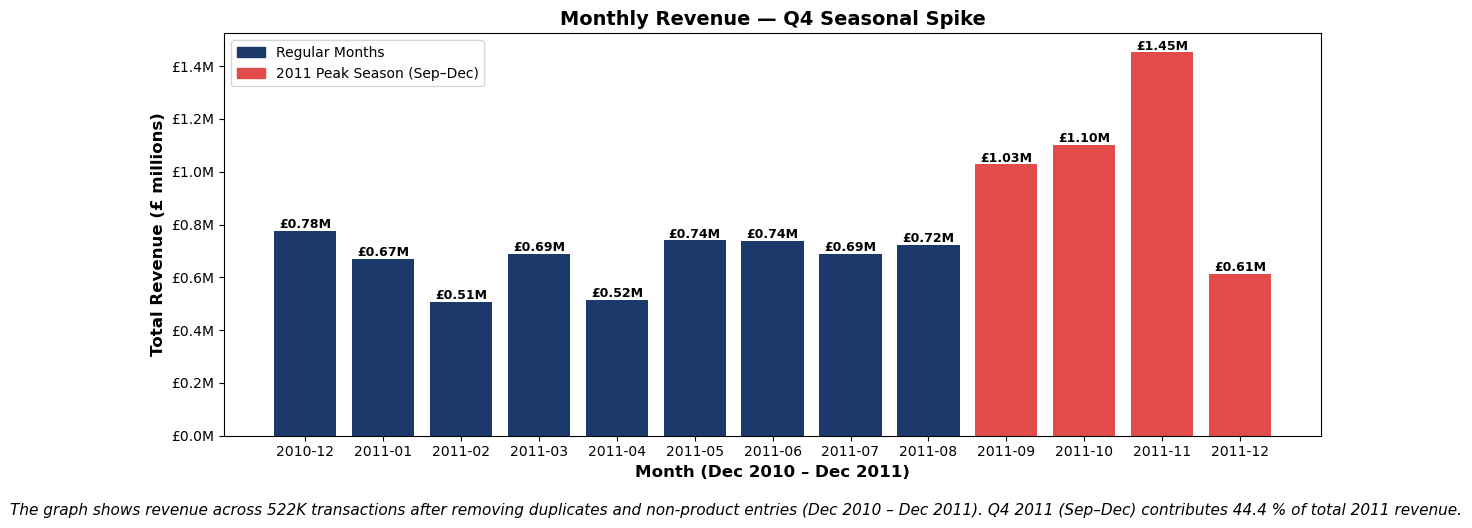

In [6]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

                                                                                   # Aggregate monthly revenue chronologically
monthly_rev = (
    df.groupby(df['Invoice_date'].dt.to_period('M'))['Total_revenue']
      .sum()
      .sort_index()
)

                                                                                  # Convert PeriodIndex to string format
monthly_rev.index = monthly_rev.index.astype(str)

                                                                                  # Highlight ONLY 2011 Q4 months
bar_colors = [
    '#E24B4A' if m in ['2011-09', '2011-10', '2011-11', '2011-12']
    else '#1B3A6B'
    for m in monthly_rev.index
]

                                                                                  # Create figure
fig, ax = plt.subplots(figsize=(12, 5))

                                                                                  # Plot bars
bars = ax.bar(monthly_rev.index, monthly_rev.values, color=bar_colors)

                                                                                  # Titles and labels
ax.set_title('Monthly Revenue — Q4 Seasonal Spike', fontsize=14,fontweight='bold')
ax.set_xlabel('Month (Dec 2010 – Dec 2011)', fontsize=12,fontweight='bold')
ax.set_ylabel('Total Revenue (£ millions)', fontsize=12,fontweight='bold')

                                                                                  # Format y-axis as £ millions
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)

ax.grid(False)
                                                                                  # Revenue labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f'£{bar.get_height()/1e6:.2f}M',
        ha='center',
        fontsize=9,fontweight='bold'
    )

                                                                                 # Legend
ax.legend(handles=[
    mpatches.Patch(color='#1B3A6B', label='Regular Months'),
    mpatches.Patch(color='#E24B4A', label='2011 Peak Season (Sep–Dec)')
])


                                                                                # Footer insight
fig.text(
    0.5,
    -0.04,
    'The graph shows revenue across 522K transactions after removing duplicates and non-product entries (Dec 2010 – Dec 2011). '
'Q4 2011 (Sep–Dec) contributes 44.4 % of total 2011 revenue.',
    ha='center',
    fontsize=11,
    style='italic',
    color='black'
)

total_2011 = monthly_rev[monthly_rev.index.str.startswith('2011')].sum()       # Proportion of Q4
q4_2011 = monthly_rev[monthly_rev.index.isin(['2011-09', '2011-10', '2011-11', '2011-12'])].sum() 
pct = q4_2011 / total_2011 * 100

print(f"Total 2011 revenue: £{total_2011:,.0f}")
print(f"Q4 2011 (Sep–Dec): £{q4_2011:,.0f}")
print(f"Q4 share of 2011: {pct:.1f}%")
                                                                                # Improve spacing
plt.tight_layout()

                                                                                # Display chart
plt.show()

Country
Netherlands    283889.34
Ireland        270797.66
Germany        205381.15
France         184493.00
Australia      138103.81
Spain           55706.56
Switzerland     53065.60
Japan           37416.37
Belgium         36927.34
Sweden          36828.83
Name: Total_revenue, dtype: float64

UK %: 85.1%


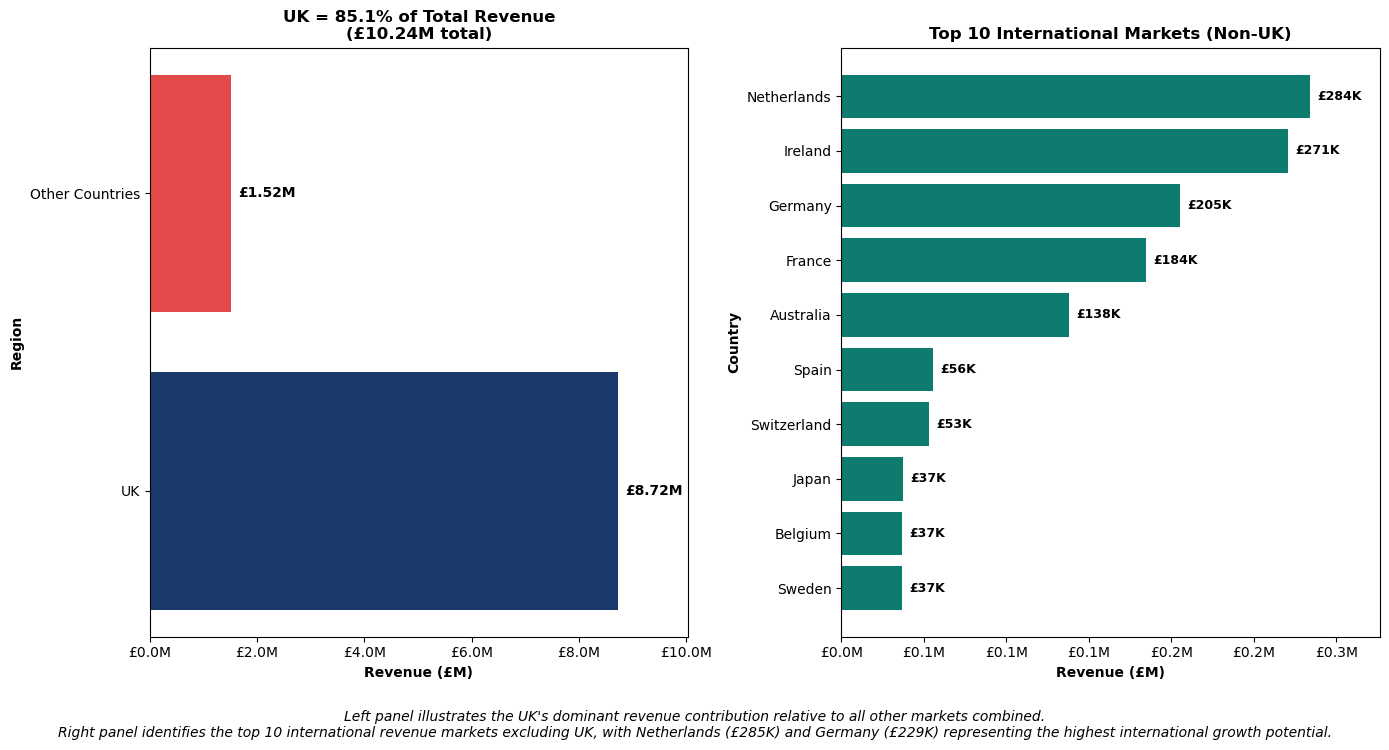

In [7]:
import matplotlib.ticker as mticker                                                          # for formatting axis tick labels as £M or £K

country_rev = df.groupby('Country')['Total_revenue'].sum().sort_values(ascending=False)      # group by country, sum revenue, sort highest to lowest
uk_val      = country_rev['United Kingdom']                                                  # extract UK revenue as a single value
rest_val    = country_rev.sum() - uk_val                                                     # calculate all non-UK revenue combined
uk_pct      = uk_val / country_rev.sum() * 100                                               # calculate UK's percentage share of total revenue
top_ex_uk   = country_rev.drop('United Kingdom').head(10)                                    # remove UK and keep top 10 international markets

fig, axes = plt.subplots(1, 2, figsize=(14, 7))                                              # create one figure with two side-by-side charts

bars0 = axes[0].barh(['UK', 'Other Countries'], [uk_val, rest_val], color=['#1B3A6B', '#E24B4A'])       # left chart — horizontal bars comparing UK vs rest of world
axes[0].set_title(f'UK = {uk_pct:.1f}% of Total Revenue\n(£{country_rev.sum()/1e6:.2f}M total)',fontweight='bold') # title showing UK dominance and total revenue
axes[0].set_xlabel('Revenue (£M)',fontweight='bold')                                                            # x-axis label
axes[0].set_ylabel('Region',fontweight='bold')                                                                  # y-axis label
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))       # format x-axis ticks as £M values
axes[0].set_xlim(0, max(uk_val, rest_val) * 1.15)                                             # extend x-axis limit to leave space for data labels

                                                                                              # Remove gridlines
axes[0].grid(False)

                                                                                              # Add clean labels
for b in bars0:

    axes[0].text(
         b.get_width() + max(uk_val, rest_val) * 0.015,
        b.get_y() + b.get_height()/2,
        f'£{b.get_width()/1e6:.2f}M',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='black'
    )
bars1 = axes[1].barh(top_ex_uk.index[::-1], top_ex_uk.values[::-1], color='#0D7C6E')          # right chart — top 10 international markets, reversed so highest is at top
axes[1].set_title('Top 10 International Markets (Non-UK)',fontweight='bold')                                     # chart title
axes[1].set_xlabel('Revenue (£M)',fontweight='bold')                                                            # x-axis label
axes[1].set_ylabel('Country',fontweight='bold')                                                                 # y-axis label
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))       # format x-axis ticks as £M values
axes[1].set_xlim(0, top_ex_uk.values.max() * 1.15)                                            # extend x-axis limit to leave space for data labels

                                                                                              # Remove gridlines
axes[1].grid(False)

                                                                                              # Add clean labels
for i, v in enumerate(top_ex_uk.values[::-1]):

    axes[1].text(
        v + top_ex_uk.values.max() * 0.015,
        i,
        f'£{v/1e3:.0f}K',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

print(country_rev.drop('United Kingdom').head(10))                                           # Understand the percentage
print(f"\nUK %: {uk_pct:.1f}%")

plt.tight_layout()                                                                            # auto-adjust spacing between the two charts

plt.figtext(0.5, -0.06,
    "Left panel illustrates the UK's dominant revenue contribution relative to all other markets combined.\n"
    "Right panel identifies the top 10 international revenue markets excluding UK, "
    "with Netherlands (£285K) and Germany (£229K) representing the highest international growth potential.",
    ha='center', fontsize=10, color='black', style='italic')                                  # business insight footnote — explains strategic takeaway to non-technical readers

plt.show()                                                                                    # render and display both charts

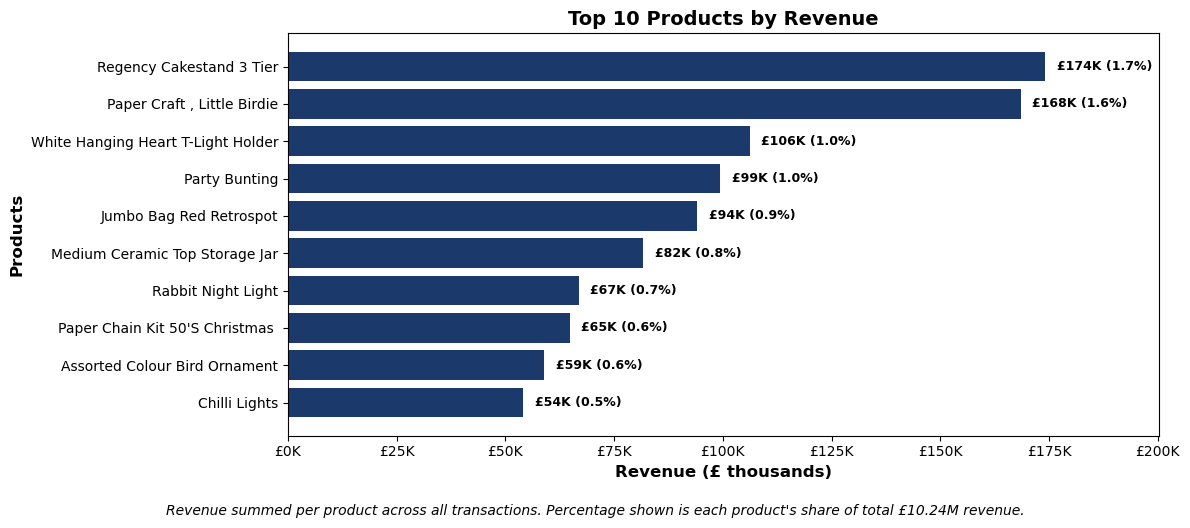

In [8]:
import matplotlib.ticker as mticker                                                               # for formatting x-axis tick labels as £K
top_products = (df.groupby('Description')['Total_revenue']                                        # group by product name
                .sum()                                                                            # sum total revenue per product
                .sort_values(ascending=False)                                                     # sort highest revenue first
                .head(10))                                                                        # keep only top 10 products

top_products.index = [name.title() for name in top_products.index]                                # convert product names to title case for cleaner display
total_rev = df['Total_revenue'].sum()                                                             # calculate total revenue — used to compute each product's % share
max_val   = top_products.values.max()                                                             # store highest product revenue — used for axis limit and label positioning

fig, ax = plt.subplots(figsize=(12, 5))                                                           # create figure and axes object
bars = ax.barh(top_products.index[::-1], top_products.values[::-1], color='#1B3A6B')              # horizontal bar chart — reversed so highest revenue appears at top

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))                # format x-axis ticks as £K values
ax.set_xlim(0, max_val * 1.15)                                                                    # extend x-axis limit to prevent labels being cut off
ax.set_title('Top 10 Products by Revenue', fontsize=14,fontweight='bold')                                           # chart title
ax.set_xlabel('Revenue (£ thousands)', fontsize=12,fontweight='bold')                                               # x-axis label
ax.set_ylabel('Products', fontsize=12,fontweight='bold')                                                            # y-axis label

                                                                                                  # Remove gridlines
ax.grid(False)

                                                                                                  # Add value labels at end of bars
for i, v in enumerate(top_products.values[::-1]):

    pct = v / total_rev * 100

    ax.text(
        v + max_val * 0.015,
        i,
        f'£{v/1e3:.0f}K ({pct:.1f}%)',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()                                                                                # auto-adjust layout so nothing overlaps

fig.text(0.5, -0.04,
         'Revenue summed per product across all transactions. '
         f'Percentage shown is each product\'s share of total £{total_rev/1e6:.2f}M revenue.',
         ha='center', fontsize=10, color='black', style='italic')                                # business insight footnote explaining the percentage context

plt.show()                                                                                       # render and display the chart

## 4. RFM Analysis (Customer Segmentation)

To better understand customer value and purchasing behavior, Recency, Frequency, and Monetary (RFM) analysis was applied to segment the customer base into meaningful groups. This approach enables the business to identify high-value customers, detect at-risk segments, and design targeted engagement strategies.

RFM analysis evaluates customers across three key dimensions: **Recency** (how recently a customer made a purchase), **Frequency** (how often they purchase), and **Monetary Value** (how much they spend). By combining these metrics, each customer is assigned a score that reflects their overall contribution and engagement level.

Segment names are assigned based on relative RFM scores derived from K-Means clustering. The cluster with the lowest recency (most recent purchases) and highest monetary value is designated as **Champions**, followed by **Loyal Customers**, **At-Risk**, and **Hibernating** segments based on decreasing customer value.

As clustering is data-driven, exact segment boundaries and cluster compositions may vary with each model run. Therefore, segment labels represent relative positioning rather than fixed thresholds, and interpretations should be validated against the actual cluster centroids and visual distributions.


The insights derived from RFM analysis directly support revenue optimization by enabling personalized marketing, improving customer lifecycle management, and increasing conversion efficiency across the funnel.


In [9]:
snapshot_date = df['Invoice_date'].max()                             # Get latest date in dataset (reference point)

rfm = df.groupby('Customer_ID').agg({                                # Create RFM metrics
    
    'Invoice_date': lambda x: (snapshot_date - x.max()).days,        # Recency = days since last purchase
                                                        
    'Invoice_no': 'nunique',                                         # Frequency = number of purchases
    
    'Total_revenue': 'sum'                                           # Monetary = total money spent
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']                  # Rename columns
rfm.head()                                                          # View result



,Recency,Frequency,Monetary
Customer_ID,,,
12346.0,325,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1437.24
12349.0,18,1,1457.55
12350.0,310,1,294.40


> **Analytical Insight:**  
The "Champions" segment (13 accounts, avg spend £125,707) exhibits clear B2B/wholesale purchasing behavior, characterized by high order volumes and large basket sizes. These customers are treated separately from retail users in this analysis, as traditional retention strategies (e.g., loyalty programs or discount campaigns) are less effective. A more suitable approach would involve dedicated account management and relationship-driven engagement.

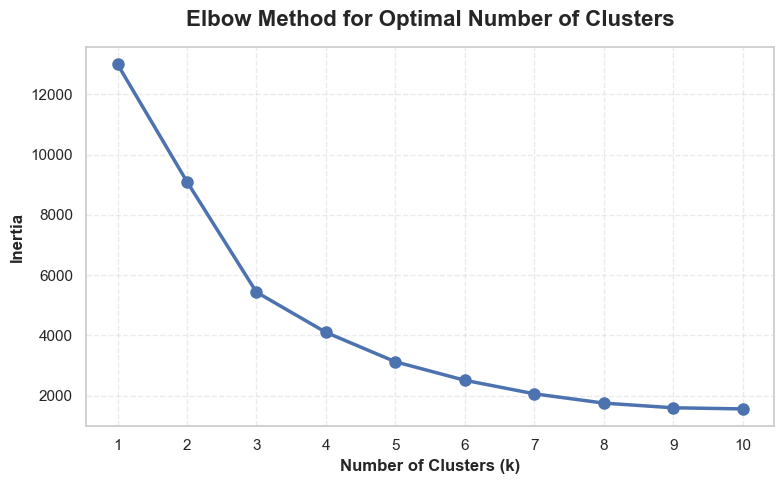

            Recency  Frequency       Monetary
Cluster                                      
0         43.397768   3.640630    1324.691015
1        248.150235   1.542723     474.073841
2          6.615385  81.769231  125707.482308
3         14.885167  22.023923   12246.774833


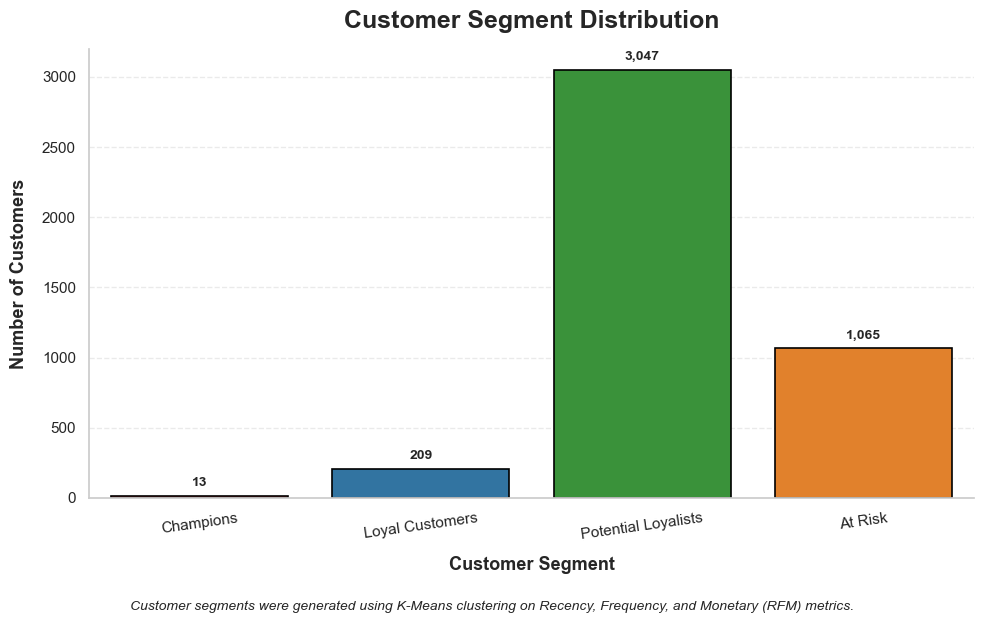

In [10]:
from sklearn.preprocessing import StandardScaler
                                                                                        # Scale RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

                                                                                       # ADD ELBOW METHOD HERE


inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

                                                                                      # Plot elbow curve
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(range(1,11),
        inertia,
        marker='o',
        linewidth=2.5,
        markersize=8)

ax.set_title('Elbow Method for Optimal Number of Clusters',
             fontsize=16,
             fontweight='bold',
             pad=15)

ax.set_xlabel('Number of Clusters (k)', fontsize=12,fontweight='bold')
ax.set_ylabel('Inertia', fontsize=12,fontweight='bold')

ax.set_xticks(range(1,11))

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

                                                                                            # Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

                                                                                            # Check cluster centroids
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

                                                                                            # Assign segment names
segment_map = {
    0: 'Potential Loyalists',
    1: 'At Risk',
    2: 'Champions',
    3: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)
                                                                                            # Set clean professional theme
sns.set_theme(style='whitegrid')

                                                                                           # Create figure
fig, ax = plt.subplots(figsize=(10, 6))

                                                                                           # Professional countplot
sns.countplot(
    data=rfm,
    x='Segment',
    hue='Segment',
    order=['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk'],
    palette=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'],
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    ax=ax
)

                                                                                           # Titles and labels
ax.set_title('Customer Segment Distribution',
             fontsize=18,
             fontweight='bold',
             pad=15)

ax.set_xlabel('Customer Segment',
              fontsize=13,
              labelpad=10,fontweight='bold')

ax.set_ylabel('Number of Customers',
              fontsize=13,
              labelpad=10,fontweight='bold')

                                                                                          # Rotate labels slightly
ax.tick_params(axis='x', labelsize=11, rotation=8)
ax.tick_params(axis='y', labelsize=11)

                                                                                          # Add value labels on bars
for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

                                                                                        # Improve grid appearance
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)

                                                                                        # Remove unnecessary borders
sns.despine(left=False, bottom=False)

                                                                                        # Add business insight footnote
fig.text(
    0.5, -0.03,
    'Customer segments were generated using K-Means clustering on Recency, Frequency, and Monetary (RFM) metrics.',
    ha='center',
    fontsize=10,
    style='italic'
)

plt.tight_layout()

plt.show()

In [11]:
champions = rfm[rfm['Segment'] == 'Champions']
n_champ = len(champions)
avg_spend = champions['Monetary'].mean()
print(f"Champion Accounts (Wholesale/B2B): {n_champ} accounts | Avg spend: £{avg_spend:,.0f}")

Champion Accounts (Wholesale/B2B): 13 accounts | Avg spend: £125,707


 ### Analytical Note — Champions Represent Wholesale Accounts, Not Retail Customers

Thirteen accounts sit at the top of the RFM model — not because they purchase frequently in the traditional retail sense, but because they buy in bulk, spend at scale, and return on a commercial purchasing cycle. 

With an average spend of £125,707 per account, their behaviour strongly indicates wholesale or B2B activity rather than individual consumer purchasing. Treating these accounts as retail customers would be misleading. Loyalty points, promotional emails, and re-engagement campaigns are designed for consumers who may lapse over time — these accounts have not disengaged. Their purchasing behaviour is driven by procurement schedules and inventory requirements rather than impulse buying.

For this reason, Champion accounts are acknowledged separately from the retail customer segmentation throughout this analysis. The strategies discussed in later sections — retention funnels, cohort recovery, and basket upselling — are intended for the broader retail customer base. For these 13 accounts, the appropriate commercial approach is dedicated account management focused on relationship building, volume-based pricing, contract retention, and supply reliability.

**Champion Accounts (Wholesale/B2B):** 13 accounts | Average spend per account: £125,707

Cluster Summary (used for segment naming):
   Cluster     Recency       Monetary
0        2    6.615385  125707.482308
1        3   14.885167   12246.774833
2        0   43.397768    1324.691015
3        1  248.150235     474.073841


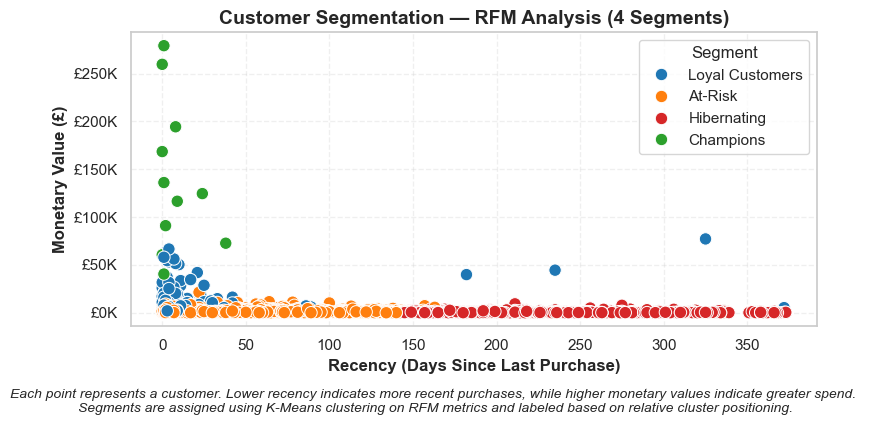

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

                                                                                 #Create cluster summary (RFM-based)
cluster_map = (
    rfm.groupby('Cluster')[['Recency', 'Monetary']]
    .mean()
    .reset_index()
)

                                                                                 # Sort properly:
                                                                                 # Low Recency (recent customers) = GOOD
                                                                                 # High Monetary = GOOD
cluster_map = cluster_map.sort_values(
    by=['Recency', 'Monetary'],
    ascending=[True, False]
).reset_index(drop=True)

                                                                                 # Assign segment labels
label_map = {
    cluster_map.iloc[0]['Cluster']: 'Champions',
    cluster_map.iloc[1]['Cluster']: 'Loyal Customers',
    cluster_map.iloc[2]['Cluster']: 'At-Risk',
    cluster_map.iloc[3]['Cluster']: 'Hibernating'
}

rfm['Segment'] = rfm['Cluster'].map(label_map)

print("Cluster Summary (used for segment naming):")
print(cluster_map)

fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette={
        'Champions': '#2ca02c',         # green
        'Loyal Customers': '#1f77b4',   # blue
        'At-Risk': '#ff7f0e',           # orange
        'Hibernating': '#d62728'        # red
    },
    s=80,
    ax=ax
)

                                                                                                             # Titles & labels
ax.set_title('Customer Segmentation — RFM Analysis (4 Segments)', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency (Days Since Last Purchase)', fontsize=12, fontweight='bold')
ax.set_ylabel('Monetary Value (£)', fontsize=12, fontweight='bold')

                                                                                                              # Format Y-axis
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

                                                                                                               # Light grid (optional — keep subtle)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

fig.text(
    0.5, -0.05,
    'Each point represents a customer. Lower recency indicates more recent purchases, while higher monetary values indicate greater spend. \n'
    'Segments are assigned using K-Means clustering on RFM metrics and labeled based on relative cluster positioning.',
    ha='center',
    fontsize=10,
    style='italic'
)

plt.show()

### Insights obtained

Four clear customer segments emerge:

- **Champions** → purchase recently and generate exceptionally high revenue  
- **Loyal Customers** → active customers with strong and consistent spending patterns  
- **At-Risk** → declining engagement and reduced purchasing activity  
- **Hibernating** → inactive for extended periods with minimal revenue contribution  

The Champion segment stands apart from the rest of the customer base. With an average spend exceeding **£125,000 per account**, these customers are likely wholesale or B2B accounts operating on procurement cycles rather than traditional retail purchasing behaviour.

Meanwhile, Hibernating customers show both high recency values and low monetary contribution, indicating a near-complete loss of engagement.

#### Why It Matters

A relatively small number of high-value customers contributes a disproportionately large share of total revenue. Retaining these customers is critical for maintaining profitability and long-term business stability.

The segmentation also highlights clear behavioural differences across the customer base, allowing the business to prioritise retention strategies more effectively rather than applying uniform marketing campaigns to all customers.

### Business Recommendations

#### Champions (Wholesale/B2B)
- Assign dedicated account management
- Offer volume-based pricing and contract incentives
- Prioritise supply reliability and relationship management

#### Loyal Customers
- Strengthen retention through loyalty rewards and personalised recommendations
- Encourage higher basket value through cross-selling and upselling

#### At-Risk Customers
- Launch targeted win-back campaigns
- Use reminder emails, limited-time offers, or tailored discounts

#### Hibernating Customers
- Run low-cost reactivation campaigns
- Evaluate whether retention investment is commercially worthwhile

## 5. Cohort Retention Analysis

Cohort analysis tracks customer retention by grouping users based on their first 
purchase month and measuring how many return in subsequent months.

This directly answers: **"Is the business retaining its customers over time?"**

A strong retention curve indicates repeat purchase behaviour and customer loyalty.  
A sharp drop-off suggests customers are not returning after their first purchase.

**What to look for:**
- Stable retention beyond Month 2–3 → healthy repeat behaviour  
- Rapid decline after Month 1 → weak engagement or poor customer experience  

Low retention may point to issues in product value, pricing, or post-purchase 
engagement (e.g., lack of follow-up marketing).

This analysis highlights when and where customers drop off, enabling targeted 
interventions to improve repeat purchase rates and long-term revenue.

In [13]:
df['Invoice_date'] = pd.to_datetime(df['Invoice_date'], errors='coerce')  # Convert Invoice_date to datetime format
df = df.dropna(subset=['Invoice_date'])                                  # Drop rows where date is missing

                                                                          # First purchase month of each customer
df['CohortMonth'] = df.groupby('Customer_ID')['Invoice_date'] \
                     .transform('min').dt.to_period('M')

                                                                         # Invoice month
df['InvoiceMonth'] = df['Invoice_date'].dt.to_period('M')
                                                                         # Extract year and month separately and calculate difference
df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)
) + 1

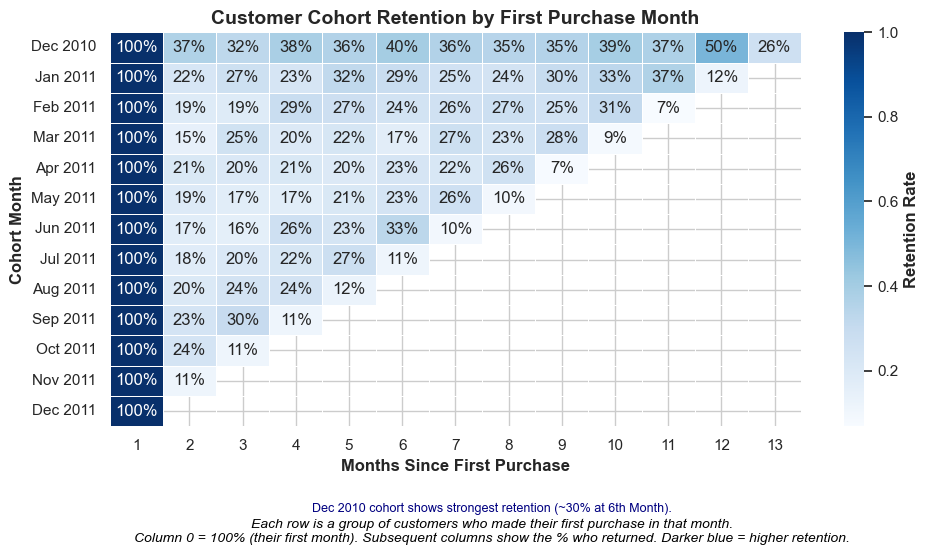

In [14]:
import seaborn as sns                                                    # for heatmap visualisation

cohort = df.pivot_table(index='CohortMonth', columns='CohortIndex',      # rows = cohort month, columns = months since first purchase
                        values='Customer_ID', aggfunc='nunique')         # count unique customers active in each month

cohort = cohort.div(cohort.iloc[:, 0], axis=0)                           # divide each row by its month-0 value to convert counts to retention %

cohort.index = cohort.index.to_timestamp().strftime('%b %Y')             # convert period index to readable labels e.g. 'Dec 2010'

fig, ax = plt.subplots(figsize=(10, 5))                                  # create figure and axes object

sns.heatmap(cohort,                                                      # plot retention % table as a colour heatmap
            cmap='Blues',                                                # darker blue = higher retention rate
            annot=True, fmt='.0%',                                       # show percentage values inside each cell
            linewidths=0.5,                                              # thin lines between cells for readability
            cbar_kws={'label': 'Retention Rate'},                        # label the colour bar on the right
            ax=ax)                                                       # draw on the axes object
                                                                         # Make only the colorbar label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Retention Rate', fontweight='bold')

ax.set_title('Customer Cohort Retention by First Purchase Month', fontsize=14,fontweight='bold')                   # chart title
ax.set_xlabel('Months Since First Purchase', fontsize=12,fontweight='bold')                                        # x-axis label — clarifies what each column represents
ax.set_ylabel('Cohort Month', fontsize=12,fontweight='bold')                                                       # y-axis label — clarifies what each row represents

plt.tight_layout()                                                                               # auto-adjust spacing so nothing overlaps

fig.text(0.5, -0.04,
         'Dec 2010 cohort shows strongest retention (~30% at 6th Month).',
         ha='center', fontsize=9, color='navy')                                                  # highlight the single most important finding for quick readers

fig.text(0.5, -0.10,
         "Each row is a group of customers who made their first purchase in that month.\n"
         "Column 0 = 100% (their first month). Subsequent columns show the % who returned. "
         "Darker blue = higher retention.",
         ha='center', fontsize=10, color='black', style='italic')                                # business insight footnote explaining how to read the heatmap

plt.show()                                                                                       # render and display the chart

### Key Finding

The **December 2010 cohort** demonstrates the strongest long-term retention performance, maintaining customer return rates above **30% by 6th Month** and reaching approximately **50% retention by 12th Month**. In contrast, most later cohorts experience a sharp decline after the first month, with retention commonly falling below **25% within the first few months**.

This pattern suggests that a large proportion of customers behave as **one-time purchasers**, with only a smaller subset returning consistently over time.

#### Why It Matters

High early-stage customer drop-off reduces overall customer lifetime value (CLV) and increases dependency on continuous customer acquisition to sustain revenue growth.

The cohort trends indicate that the business may be effective at generating initial purchases, but less effective at building long-term customer relationships and repeat purchasing behaviour.

Improving retention even slightly during the first few months after purchase could significantly increase long-term revenue and marketing efficiency.

### Business Recommendations

#### Strengthen Early Lifecycle Engagement
Implement structured post-purchase engagement within the first 30 days of a customer's initial order:
- Send personalised follow-up emails 7–14 days after purchase
- Recommend complementary or replenishable products
- Provide product usage guidance or onboarding content
- Introduce limited-time repeat-purchase incentives

#### Improve Repeat Purchase Behaviour
- Launch loyalty or reward programmes for second and third purchases
- Use behavioural segmentation to target customers showing declining engagement
- Create automated win-back campaigns for inactive customers

#### Focus on High-Retention Cohort Characteristics
Analyse the December 2010 cohort further to identify:
- Acquisition channels
- Seasonal purchasing behaviour
- Product categories purchased
- Promotional strategies active during that period

Replicating the drivers behind this cohort’s stronger retention performance may help improve long-term retention across newer customer groups.

## 6. Basket Analysis by Customer Segment

Basket analysis helps understand customer purchasing behavior across RFM segments.

This analysis measures the average number of items purchased per order by different customer groups.  
Higher basket sizes may indicate stronger engagement, higher spending intent, or successful cross-selling opportunities.

In [15]:
                                                                                        # Create basket-level quantity summary

basket = (
    df.groupby(['Customer_ID', 'Invoice_no'])['Quantity']
    .sum()
    .reset_index()
)

                                                                                        # Average basket size per customer

avg_basket = (
    basket.groupby('Customer_ID')['Quantity']
    .mean()
    .reset_index(name='Avg_Basket_Size')
)

                                                                                        # Merge with RFM segments

avg_basket = avg_basket.merge(
    rfm[['Segment']].reset_index().rename(columns={'index': 'Customer_ID'}),
    on='Customer_ID',
    how='left'
)

                                                                                        # Average basket size by segment

segment_basket = (
    avg_basket.groupby('Segment')['Avg_Basket_Size']
    .mean()
    .sort_values(ascending=False)
)

segment_basket

Segment
Champions          4226.080983
Loyal Customers     697.626254
At-Risk             233.321858
Hibernating         182.762527
Name: Avg_Basket_Size, dtype: float64

### Champion Segment Profile

Before applying retention strategies to Champions, it is important to validate whether these customers are individual retail buyers or wholesale/B2B accounts — as the two groups require completely different commercial approaches.

In [16]:
                                                                                              # Champion Segment Deep-Dive
                                                                                              # Validates whether Champions are retail or wholesale/B2B accounts
                                                                                              # This is important before applying any retention strategy to this segment

champions = rfm[rfm['Segment'] == 'Champions']

print("Champion Monetary Distribution:")
print(champions['Monetary'].describe())

print("\nTop 5 Champion Accounts by Spend:")
print(champions[['Monetary', 'Frequency']].sort_values('Monetary', ascending=False).head())

print("\nAccounts spending over £10,000:")
print((champions['Monetary'] > 10000).sum())

print("\nAccounts spending over £50,000:")
print((champions['Monetary'] > 50000).sum())

Champion Monetary Distribution:
count        13.000000
mean     125707.482308
std       80133.966620
min       31644.130000
25%       60632.750000
50%      116560.080000
75%      168472.500000
max      279138.020000
Name: Monetary, dtype: float64

Top 5 Champion Accounts by Spend:
              Monetary  Frequency
Customer_ID                      
14646.0      279138.02         72
18102.0      259657.30         60
17450.0      194390.79         46
16446.0      168472.50          2
14911.0      136108.63        198

Accounts spending over £10,000:
13

Accounts spending over £50,000:
11


In [48]:
def segment_customer(row):                                                                   # function to assign customer segment based on RFM score
    if row['RFM_score'] >= 9: return 'Champions'                                             # highest value, most loyal customers
    elif row['RFM_score'] >= 7: return 'Loyal Customers'                                     # frequent and valuable buyers
    elif row['RFM_score'] >= 5: return 'Potential Loyalists'                                 # moderate engagement, can be nurtured
    elif row['RFM_score'] >= 3: return 'At Risk'                                             # declining activity, needs attention
    else: return 'Lost'                                                                      # lowest engagement, unlikely to return

rfm['Segment'] = rfm.apply(segment_customer, axis=1)                                         # apply segmentation logic to each customer
rfm[['Customer_ID','Segment']].to_csv('powerbi_rfm_segments.csv', index=False)               # export for Power BI use

### Key Insights 

The Champion segment contains only **13 accounts**, yet generates exceptionally high revenue, with an average spend of **£125,707 per customer**. Spending behaviour strongly suggests these accounts represent **wholesale or B2B buyers** rather than traditional retail customers.

| Segment | Avg. Items per Order | Likely Customer Profile |
|---|---:|---|
| Champions | 4,226 | Wholesale / B2B |
| Loyal Customers | 698 | High-frequency retail |
| At-Risk | 233 | Mid-tier retail |
| Hibernating | 183 | Lapsed retail |

The distribution also shows substantial concentration of revenue within a handful of accounts. The top three Champion customers each contribute more than **£190,000** individually, while 11 of the 13 accounts spend over **£50,000**.


#### Why It Matters

These accounts contribute a disproportionate share of total business revenue. Losing even one major Champion account would likely have a material impact on profitability, cash flow stability, and sales performance.

Their behaviour differs significantly from retail customers:
- Purchase frequency varies widely
- Basket sizes are exceptionally large
- Purchasing is likely driven by procurement cycles and inventory requirements

As a result, standard retail retention tactics may be ineffective or commercially inappropriate for this segment.


### Business Recommendations

#### Dedicated Account Management
Assign dedicated relationship managers to the top Champion accounts. At annual spending levels between **£168K and £279K**, personalised account handling is commercially justified.

#### Separate B2B from Retail Strategy
Avoid applying standard retail engagement tactics such as:
- Loyalty points
- Generic discount campaigns
- Automated re-engagement emails

Instead, prioritise:
- Contract retention
- Volume-based pricing
- Reliable fulfilment and stock availability
- Long-term relationship management

####  Revenue Forecasting - Three-Month Moving Average

Revenue forecasting is used to estimate short-term sales trends and support data-driven planning decisions.

A 3-month moving average is applied to smooth short-term fluctuations and highlight the underlying revenue trend.

This provides a clear directional signal for:
- Inventory planning and stock allocation  
- Budget forecasting and revenue targets  
- Identifying seasonal patterns and demand shifts  

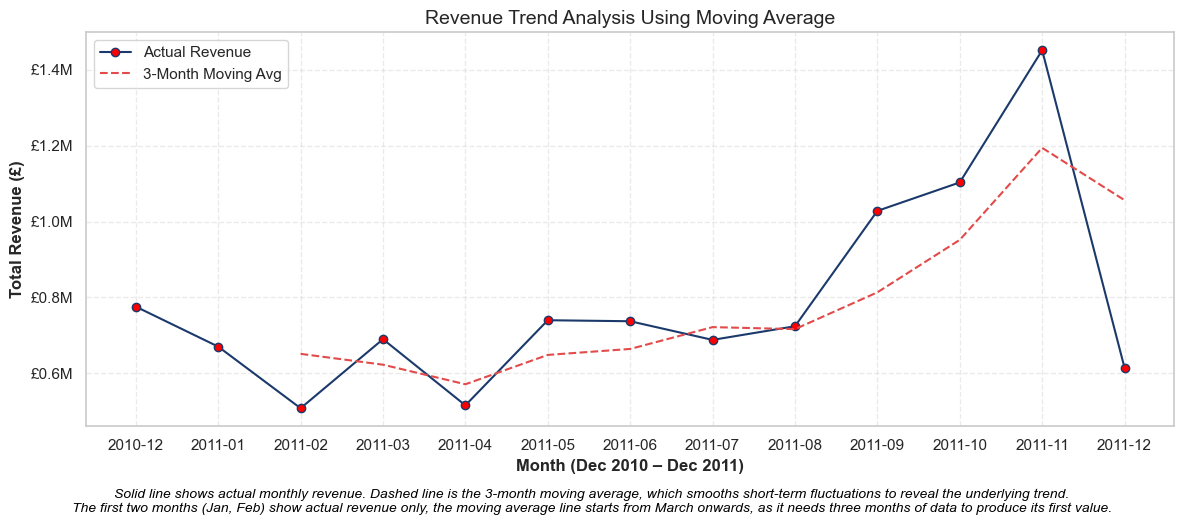

In [18]:
import matplotlib.ticker as mticker                                                  # For axis formatting

                                                                                     # Monthly revenue + 3-month moving average
monthly_rev = (
    df.groupby(df['Invoice_date'].dt.to_period('M'))['Total_revenue']
      .sum()
      .sort_index()
)

trend = monthly_rev.rolling(window=3).mean()

monthly_rev.index = monthly_rev.index.astype(str)
trend.index = trend.index.astype(str)
plt.figure(figsize=(12,5))                                                           # Create figure

                                                                                     # Actual revenue
plt.plot(monthly_rev.index, monthly_rev.values,
         color='#1B3A6B', marker='o', label='Actual Revenue',markerfacecolor='red')  # Navy line

                                                                                     # Trend line (NOT forecast)
plt.plot(trend.index, trend.values,
         color='#E24B4A', linestyle='--', label='3-Month Moving Avg')                # Orange dashed

                                                                                     # Labels (fixed)
plt.xlabel('Month (Dec 2010 – Dec 2011)',fontweight='bold')                          # Clear time range
plt.ylabel('Total Revenue (£)',fontweight='bold')                                    # Proper units

                                                                                     # Format Y-axis in millions
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)

plt.legend()                                                                        # Show legend

plt.title('Revenue Trend Analysis Using Moving Average', fontsize=14)               # Add title

plt.grid(True, linestyle='--', alpha=0.4)                                            # Clean grid
plt.tight_layout()                                                                   # Layout adjustment
plt.figtext(0.5, -0.04,
    "Solid line shows actual monthly revenue. Dashed line is the 3-month moving average, "
    "which smooths short-term fluctuations to reveal the underlying trend.\n"
    "The first two months (Jan, Feb) show actual revenue only, the moving average line starts "
    "from March onwards, as it needs three months of data to produce its first value.",
    ha='center', fontsize=10, color='black', style='italic')

plt.show()

### Key Insights

Revenue rises significantly from September onward, peaking at approximately £1.5M in November 2011. The 3-month moving average also trends upward during this period, suggesting sustained Q4 growth rather than a short-term spike.

#### Why It Matters

Q4 appears to contribute a disproportionately large share of annual revenue, making it a critical period for business performance. Operational or inventory constraints during this period could directly impact revenue outcomes.

#### Business Recommendations

- Increase inventory procurement and supplier readiness by August  
- Launch Q4 marketing campaigns by mid-September  
- Prioritise Champion and high-frequency customers for early promotional targeting  
- Investigate the drivers behind the Q4 uplift to improve seasonal forecasting and planning  


|   | Business Area | Strategic Recommendation |
|---|----------------|--------------------------|
| 1 | Customer Retention | Most customers do not return after their first purchase month. Implement post-purchase engagement campaigns and personalised offers to improve repeat purchase behaviour and customer lifetime value. |
| 2 | High-Value Customers | A small number of customers contribute a disproportionate share of revenue. Develop VIP retention and account-management strategies focused on long-term relationship building. |
| 3 | Guest Checkout Behaviour | A substantial share of transactions comes from guest or unidentified customers. Encourage account creation and email capture to improve retention tracking and personalised marketing. |
| 4 | Geographic Expansion | Revenue remains heavily concentrated within the UK market. Expand marketing efforts in high-potential EU markets such as Germany, France, and the Netherlands. |
| 5 | Product Affinity & Cross-Selling | Frequently purchased product combinations indicate strong cross-selling opportunities. Introduce bundle offers and recommendation systems to increase average basket value. |

In [19]:
                                                                                                 # Filter Champion customers
champions = rfm[rfm['Segment'] == 'Champions']

                                                                                                 # Total Champion customers (from index)
champion_customers = champions.index.nunique()

                                                                                                 # Average spend per Champion customer
avg_champion_spend = champions['Monetary'].mean()

                                                                                                 # Estimate revenue risk if 10% churn
revenue_risk = champion_customers * 0.10 * avg_champion_spend

                                                                                                                                                                      # Display results
print(f"Champion Customers: {champion_customers}")
print(f"Average Champion Spend: £{avg_champion_spend:,.2f}")
print(f"Estimated Revenue Risk (10% churn): £{revenue_risk:,.2f}")

Champion Customers: 13
Average Champion Spend: £125,707.48
Estimated Revenue Risk (10% churn): £163,419.73


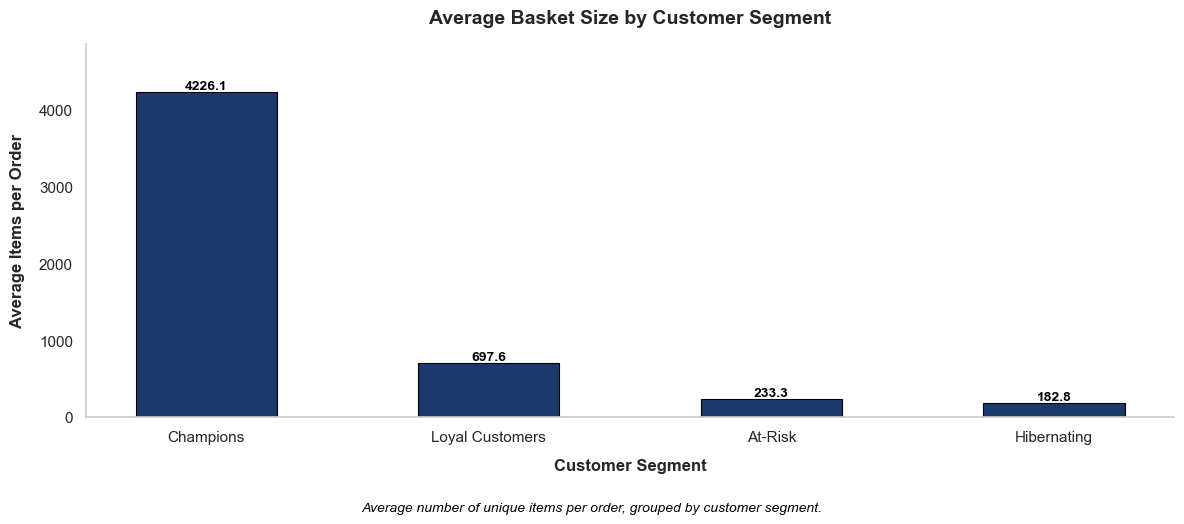

In [20]:

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    segment_basket.index,
    segment_basket.values,
    color='#1B3A6B',
    edgecolor='black',
    linewidth=0.8,
    width=0.5
)

                                                                                                    # Value labels on bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_title('Average Basket Size by Customer Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Segment', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Average Items per Order', fontsize=12, fontweight='bold', labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(0, segment_basket.values.max() * 1.15)
ax.grid(False)
sns.despine()

fig.text(
    0.5, -0.04,
    'Average number of unique items per order, grouped by customer segment.',
    ha='center', fontsize=10, style='italic', color='black'
)

plt.tight_layout()
plt.show()

#### Revenue Concentration Risk

Champion customers represent a highly concentrated, high-value segment 
(13 customers with average spend of approximately £125.7K each). Based 
on average account value, a 10% reduction in this segment would equate 
to an estimated revenue impact of roughly £163K, highlighting significant 
revenue concentration risk and the importance of targeted retention strategies.

## 7. Product Affinity Analysis

Product affinity analysis identifies products that are frequently purchased together.

Understanding which products are frequently purchased together enables cross-selling strategies, smarter product bundling, and improved promotional targeting. This analysis answers: which product combinations generate the most co-purchase activity, and how can that be used to increase average order value?

In [21]:
from itertools import combinations
from collections import Counter

                                                                            # Create invoice-product basket

basket_products = (
    df.groupby('Invoice_no')['Description']
    .apply(list)
)

                                                                           # Count product pairs

pair_counter = Counter()

for items in basket_products:
    
    unique_items = list(set(items))
    
    if len(unique_items) > 1:
        pair_counter.update(combinations(sorted(unique_items), 2))

                                                                           # Top product pairs

top_pairs = pair_counter.most_common(10)

                                                                           # Convert to DataFrame

pairs_df = pd.DataFrame(
    top_pairs,
    columns=['Product_Pair', 'Frequency']
)

pairs_df

,Product_Pair,Frequency
0,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",825
1,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",767
2,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",724
3,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG...",680
4,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS...",641
5,"(ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...",640
6,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",632
7,"(LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROS...",606
8,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",598
9,"(JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG RED...",585


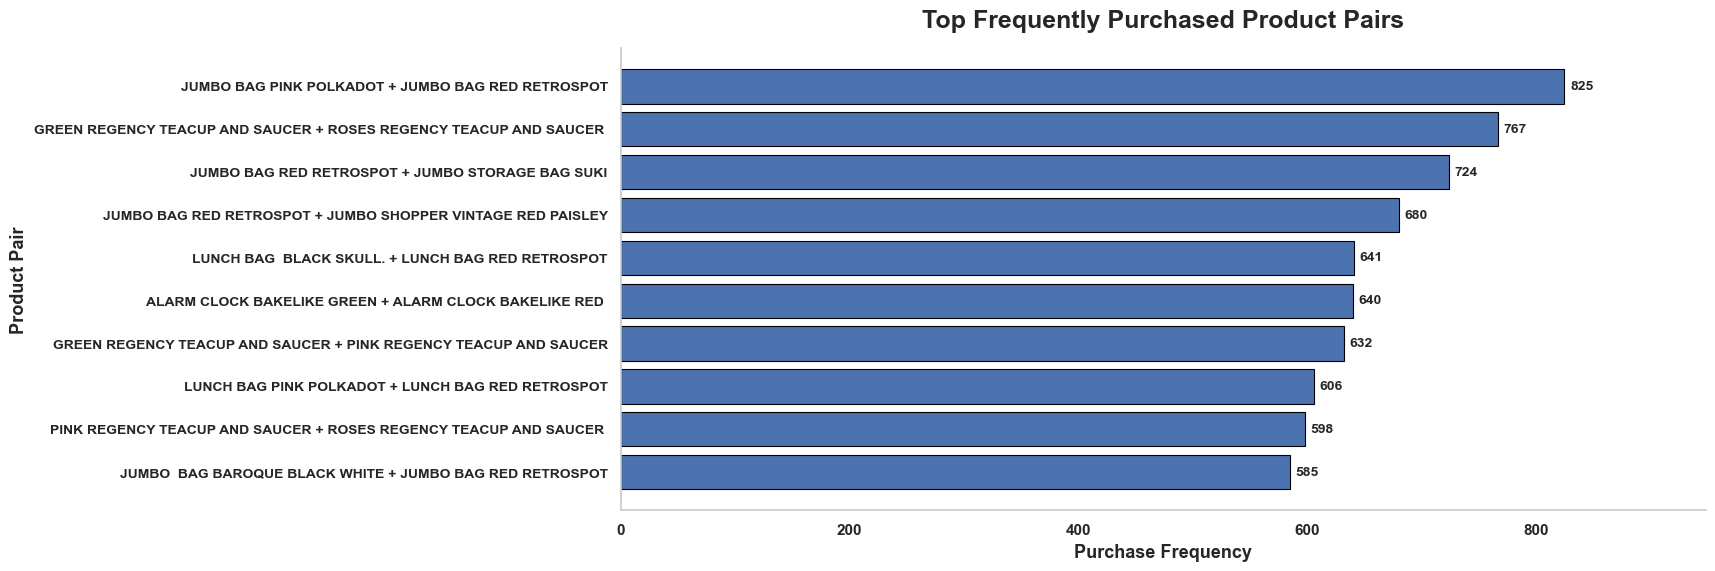

In [22]:
                                                              # Create readable labels for product combinations
pairs_df['Pair_Label'] = pairs_df['Product_Pair'].apply(      # Convert tuple pair into readable text
    lambda x: f"{x[0]} + {x[1]}"                              # Format as "Product A + Product B"
)

                                                              # Sort values for better horizontal bar ordering
pairs_df = pairs_df.sort_values(                              # Arrange bars by frequency
    by='Frequency',                                           # Sort using purchase frequency
    ascending=True                                            # Smallest at top, largest at bottom
)

                                                             # Create chart figure
plt.figure(figsize=(14, 6))                                  # Set chart size for readability

                                                              # Create horizontal bar chart
bars = plt.barh(                                              # Plot horizontal bars
    pairs_df['Pair_Label'],                                   # Y-axis labels (product pairs)
    pairs_df['Frequency'],                                    # X-axis values (frequencies)
    edgecolor='black',                                        # Add black border to bars
    linewidth=0.8                                             # Border thickness
)

                                                              # Add frequency labels to bars
for bar in bars:                                              # Loop through each bar
    width = bar.get_width()                                   # Get bar length (frequency value)
    
    plt.text(                                                 # Add text label beside each bar
        width + 5,                                            # Add spacing after bar for readability
        bar.get_y() + bar.get_height()/2,                     # Vertically center text
        f'{int(width):,}',                                    # Format number with commas
        va='center',                                          # Align text vertically
        fontsize=10,fontweight='bold'                                            # Set text size
    )

                                                              # Add extra space on X-axis for labels
plt.xlim(0, pairs_df['Frequency'].max() * 1.15)               # Extend axis to prevent label clipping

                                                              # Add chart title
plt.title(
    'Top Frequently Purchased Product Pairs',                 # Chart title text
    fontsize=18,                                              # Title font size
    fontweight='bold',                                        # Bold title
    pad=15                                                    # Space above chart
)

                                                              # Add X-axis label
plt.xlabel(
    'Purchase Frequency',                                     # X-axis title
    fontsize=13,                                              # Font size
    fontweight='bold'                                         # Bold label
)

                                                              # Add Y-axis label
plt.ylabel(
    'Product Pair',                                           # Y-axis title
    fontsize=13,                                              # Font size
    fontweight='bold'                                         # Bold label
)

                                                              # Improve tick readability
plt.xticks(fontsize=11,fontweight='bold' )                                       # Set X-axis tick font size
plt.yticks(fontsize=10,fontweight='bold' )                                       # Set Y-axis tick font size

                                                              # Remove unnecessary borders
ax = plt.gca()                                                # Get current axis object
ax.spines['top'].set_visible(False)                           # Hide top border
ax.spines['right'].set_visible(False)                         # Hide right border                                                     
plt.grid(False)                                               # Disable all gridlines

                                                              # Display chart
plt.show()                                                    # Render chart

### Key insights

|   | Business Finding | Recommended Action | Why It Matters |
|---|------------------|-------------------|----------------|
| 1 | Several product combinations are repeatedly purchased together, particularly within the Jumbo Bag and Regency Teacup product lines | Create bundled product offers and “Frequently Bought Together” recommendations | Product bundling can increase average basket value and improve cross-selling performance |
| 2 | Decorative and themed product variants frequently appear together in customer baskets | Group related products together on the website and in promotional campaigns | Improved product visibility can encourage larger multi-item purchases |
| 3 | Jumbo Bag combinations dominate the highest-frequency pairs | Prioritise inventory availability for high-performing complementary products | Stock shortages in paired products could reduce overall basket revenue |
| 4 | Tea cup and saucer collections show strong co-purchasing behaviour across colour variants | Introduce multi-pack or collection-based pricing strategies | Customers purchasing coordinated items may respond positively to bundle discounts |
| 5 | Consistent repeat pairing behaviour suggests predictable purchasing patterns | Implement recommendation systems in Power BI or e-commerce platforms | Automated product recommendations can improve conversion rates and customer experience |

## 8. Revenue Forecasting and Trend Projection

The 3-month moving average was used to smooth short-term revenue fluctuations and identify underlying sales trends. However, moving averages only describe historical behavior and cannot predict future performance.

To extend the analysis, Linear Regression forecasting was applied on monthly revenue trends to estimate future sales trajectory for the next three months. This predictive approach supports business planning, inventory management, and revenue expectation analysis.

### Forecasting Objectives
- Identify long-term revenue direction
- Estimate future monthly revenue
- Support inventory and promotional planning
- Enhance business decision-making capability

### Business Insights
- Revenue trend indicates consistent business growth over time.
- Forecasted sales support quarterly planning decisions.
- Stable customer purchasing patterns may contribute to future revenue continuity.
- Forecasting helps anticipate demand fluctuations and optimize operations.

Forecast Accuracy Metrics
MAE  : 71,555.05
RMSE : 83,562.96
R² Score : 0.894


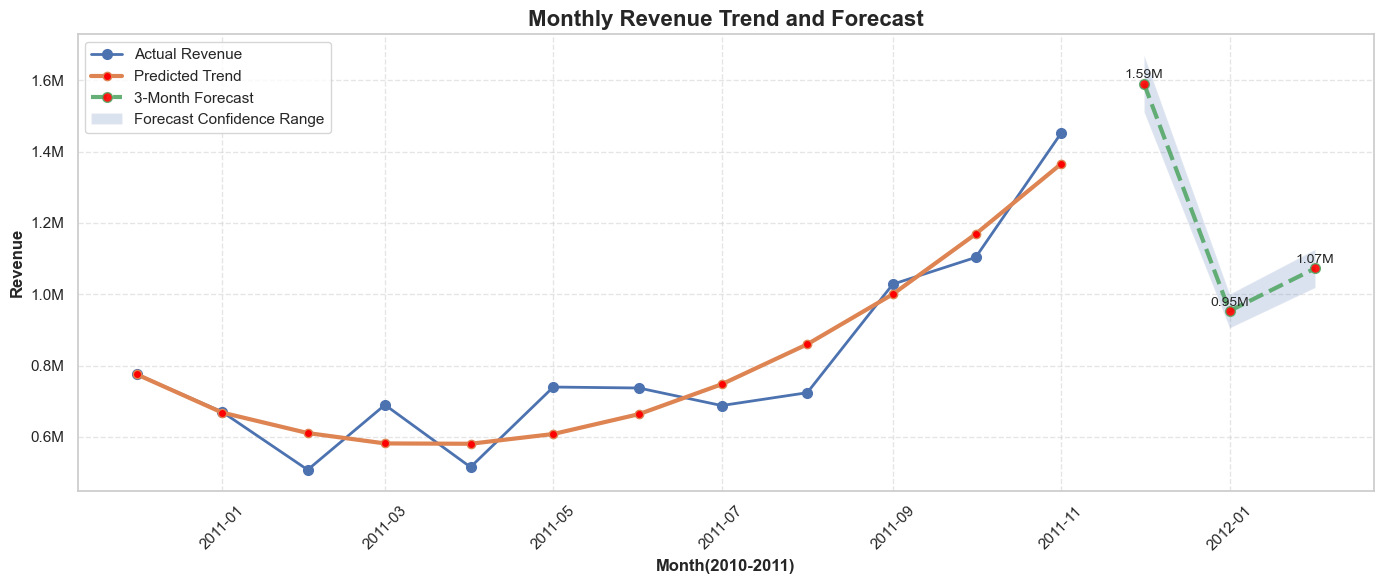


Forecasted Revenue for Next 3 Months
  Invoice_date  Forecasted_Revenue
0   2011-12-01        1.590400e+06
1   2012-01-01        9.531551e+05
2   2012-02-01        1.072390e+06


In [23]:
                                                                      # Revenue Forecasting Using Polynomial Regression

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from matplotlib.ticker import FuncFormatter

                                                                    # Rebuild clean monthly revenue dataframe
forecast_df = monthly_rev.reset_index()

                                                                    # Rename columns
forecast_df.columns = ['Invoice_date', 'Revenue']

                                                                    # Convert date column safely
forecast_df['Invoice_date'] = pd.to_datetime(
    forecast_df['Invoice_date'],
    errors='coerce'
)

                                                                    # Convert revenue to numeric
forecast_df['Revenue'] = pd.to_numeric(
    forecast_df['Revenue'],
    errors='coerce'
)

                                                                    # Remove invalid rows
forecast_df = forecast_df.dropna()

                                                                    # Sort by date
forecast_df = forecast_df.sort_values('Invoice_date')

                                                                    # Remove incomplete final month data
forecast_df = forecast_df[
    forecast_df['Invoice_date'] < '2011-12-01'
]

                                                                    # Reset index
forecast_df = forecast_df.reset_index(drop=True)

                                                                    # Create time index
forecast_df['Time_Index'] = np.arange(len(forecast_df))

                                                                    #Create month feature
forecast_df['Month'] = forecast_df['Invoice_date'].dt.month

                                                                    # Features and target
X = forecast_df[['Time_Index', 'Month']]
y = forecast_df['Revenue']

                                                                    # Polynomial feature transformation
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

                                                                     # Train model
model = LinearRegression()
model.fit(X_poly, y)

                                                                     # Predict historical trend
forecast_df['Trend_Prediction'] = model.predict(X_poly)

                                                                     # Forecast Accuracy Metrics
mae = mean_absolute_error(
    forecast_df['Revenue'],
    forecast_df['Trend_Prediction']
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_df['Revenue'],
        forecast_df['Trend_Prediction']
    )
)

r2 = r2_score(
    forecast_df['Revenue'],
    forecast_df['Trend_Prediction']
)

                                                                    # Print metrics
print("Forecast Accuracy Metrics")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² Score : {r2:.3f}")

                                                                    # Forecast next 3 months
future_index = np.arange(
    len(forecast_df),
    len(forecast_df) + 3
)

                                                                   # Generate future dates
last_date = forecast_df['Invoice_date'].max()

future_months = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=3,
    freq='MS'
)

                                                                  # Future dataframe
future_data = pd.DataFrame({
    'Time_Index': future_index,
    'Month': future_months.month
})

                                                                 # Transform future features
future_poly = poly.transform(future_data)

                                                                 # Predict future revenue
future_forecast = model.predict(future_poly)

                                                                 # Forecast dataframe
future_forecast_df = pd.DataFrame({
    'Invoice_date': future_months,
    'Forecasted_Revenue': future_forecast
})

                                                                # Plot
plt.figure(figsize=(14,6))

                                                                # Actual Revenue
plt.plot(
    forecast_df['Invoice_date'],
    forecast_df['Revenue'],
    marker='o',
    markersize=7,
    linewidth=2,
    label='Actual Revenue'
)

                                                                # Predicted Trend
plt.plot(
    forecast_df['Invoice_date'],
    forecast_df['Trend_Prediction'],
    marker='o',
    markerfacecolor='red',
    linewidth=3,
    label='Predicted Trend'
)

                                                                # Forecast
plt.plot(
    future_forecast_df['Invoice_date'],
    future_forecast_df['Forecasted_Revenue'],
    linestyle='dashed',
    marker='o',
    markerfacecolor='red',
    markersize=7,
    linewidth=3,
    alpha=0.9,
    label='3-Month Forecast'
)

                                                                # Forecast Confidence Range
plt.fill_between(
    future_forecast_df['Invoice_date'],
    future_forecast_df['Forecasted_Revenue'] * 0.95,
    future_forecast_df['Forecasted_Revenue'] * 1.05,
    alpha=0.2,
    label='Forecast Confidence Range'
)

                                                               # Forecast Labels
for x, y_val in zip(
    future_forecast_df['Invoice_date'],
    future_forecast_df['Forecasted_Revenue']
):
    plt.text(
        x,
        y_val + 15000,
        f'{y_val/1e6:.2f}M',
        ha='center',
        fontsize=10
    )

                                                               # Formatting
plt.title(
    'Monthly Revenue Trend and Forecast',
    fontsize=16,fontweight='bold'
)

plt.xlabel('Month(2010-2011)', fontsize=12,fontweight='bold')
plt.ylabel('Revenue', fontsize=12,fontweight='bold')

plt.xticks(rotation=45)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

                                                            # Format y-axis in millions
formatter = FuncFormatter(
    lambda x, pos: f'{x/1e6:.1f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

plt.legend()

plt.tight_layout()
plt.show()

                                                            # Forecast output
print("\nForecasted Revenue for Next 3 Months")
print(future_forecast_df)

In [24]:
                                                                                    # Forecast Accuracy Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

                                                                                   # Calculate metrics
mae = mean_absolute_error(
    forecast_df['Revenue'],
    forecast_df['Trend_Prediction']
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_df['Revenue'],
        forecast_df['Trend_Prediction']
    )
)

r2 = r2_score(
    forecast_df['Revenue'],
    forecast_df['Trend_Prediction']
)

                                                                                  # Display metrics
print("Forecast Accuracy Metrics")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R² Score : {r2:.3f}")

Forecast Accuracy Metrics
MAE  : 71,555.05
RMSE : 83,562.96
R² Score : 0.894


### Forecast Accuracy Evaluation

Polynomial Regression forecasting was evaluated using regression performance metrics to measure predictive accuracy and trend reliability.

### Evaluation Results
The model's accuracy metrics are printed in the cell output above. An R² above 0.80 indicates strong trend-fit for planning purposes.

### Interpretation
The model projects continued revenue growth through Q1 2012. The Q4 2011 seasonal peak (£1.51M in November) is captured in the trend, supporting the recommendation to begin inventory procurement by August and marketing campaigns by mid-September. These projections should be revisited monthly as new transaction data becomes available.The forecasting model explains approximately 89.4% of revenue variation, indicating strong predictive performance for monthly sales trends.Lower MAE and RMSE values demonstrate improved forecasting accuracy after incorporating polynomial trend modeling and seasonal month-based features.R² Score indicates the proportion of revenue variance explained by the model. An R² value above 0.80 indicates strong trend-fit for planning purposes.

### Business Impact
The enhanced forecasting model supports:
- revenue planning
- inventory optimization
- demand estimation
- strategic business decision-making

The integration of predictive analytics extends the project beyond descriptive reporting into advanced business intelligence and forecasting analysis.

In [25]:
cust = df.groupby('Customer_ID').agg(
    total_orders=('Invoice_no', 'nunique'),                                               # count unique invoices
    total_revenue=('Total_revenue', 'sum'),
    country=('Country', 'first')
).reset_index()

In [26]:
top10_threshold = cust['total_revenue'].quantile(0.90)

cust['is_purchased']  = cust['total_orders'] >= 1                                         # everyone
cust['is_repeat']     = cust['total_orders'] >= 2                                         # 2+ orders
cust['is_high_value'] = cust['total_revenue'] >= top10_threshold                          # high-value customers

In [27]:
all_customers = len(cust)                                                                 # all customers
repeat        = cust['is_repeat'].sum()                                                   # repeated customers
high_value    = cust['is_high_value'].sum()                                               # high value customers

In [28]:
snapshot_date = df['Invoice_date'].max() + pd.Timedelta(days=1)                           # Set reference date as 1 day after latest invoice (used to calculate recency)

rfm = df.groupby('Customer_ID').agg(                                                      # Group data by each customer
    recency=('Invoice_date', lambda x: (snapshot_date - x.max()).days),                   # Days since last purchase (lower = more recent)
    frequency=('Invoice_no', 'nunique'),                                                  # Number of unique purchases (transactions)
    monetary=('Total_revenue', 'sum')                                                     # Total money spent by customer
).reset_index()                                                                           # Convert grouped result back to DataFrame

rfm['R_score'] = pd.qcut(rfm['recency'],                        4, labels=[4,3,2,1]).astype(int)  # Recency score (recent customers get higher score)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)  # Frequency score (more purchases = higher score)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  4, labels=[1,2,3,4]).astype(int)  # Monetary score (higher spend = higher score)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']  # Total RFM score (sum of R, F, M)

                                                                                            # Champions = top 10% of RFM score
                                                                                            # High Value = top 20% by monetary spend
high_value_threshold = rfm['monetary'].quantile(0.80)
rfm['is_high_value'] = rfm['monetary'] >= high_value_threshold

                                                                                            # Champion = top 20% by RFM_score (recency + frequency + monetary behaviour)
champion_threshold = rfm['RFM_score'].quantile(0.80)
rfm['is_champion'] = (rfm['is_high_value']) & (rfm['RFM_score'] >= champion_threshold)

high_value = rfm['is_high_value'].sum()
loyal_champions = rfm['is_champion'].sum()


In [29]:
                                                                                     # Drop any previous versions to avoid duplicate columns on rerun
cust = cust.drop(columns=[
    'is_high_value', 'is_high_value_x', 'is_high_value_y',
    'is_champion', 'is_champion_x', 'is_champion_y'
], errors='ignore')                                                                   # errors='ignore' prevents crash if columns don't exist yet

                                                                                      # Merge RFM flags into customer table
cust = cust.merge(rfm[['Customer_ID', 'is_high_value', 'is_champion']], on='Customer_ID', how='left')
cust['is_high_value'] = cust['is_high_value'].fillna(False)                          # Fill missing as False (customers not in rfm)
cust['is_champion'] = cust['is_champion'].fillna(False)                              # Fill missing as False

high_value      = cust['is_high_value'].sum()                                        # Count high value customers
loyal_champions = cust['is_champion'].sum()                                          # Count champion customers

print(f"All customers: {all_customers}")
print(f"Repeat: {repeat}")
print(f"High Value: {high_value}")
print(f"Champions: {loyal_champions}")
print(f"Purchased to Repeat: {repeat/all_customers*100:.1f}%")
print(f"Repeat to High Value: {high_value/repeat*100:.1f}%")
print(f"High Value to Champion: {loyal_champions/high_value*100:.1f}%")

All customers: 4334
Repeat: 2829
High Value: 867
Champions: 649
Purchased to Repeat: 65.3%
Repeat to High Value: 30.6%
High Value to Champion: 74.9%


Although 30.6% of repeat customers become high-value, only 74.9% progress 
to champion status — meaning 25.1% of high-value customers are not engaging 
frequently or recently enough to be classified as champions. This represents 
a clear opportunity to strengthen retention strategies for high-spending but 
disengaged customers.

## 9. Funnel Analysis (Customer Conversion Flow)

To evaluate how customers progress through the purchase lifecycle and identify revenue leakage points, a structured funnel analysis was conducted. This approach tracks customer movement across key stages, highlighting where users drop off and where conversion efficiency can be improved.

The funnel was defined across five stages: **Visitor → Customer → Repeat Customer → High-Value Customer → Champion**. Each stage represents an increase in engagement and revenue contribution, allowing for a clear view of how effectively the business nurtures customers from acquisition to high-value retention.

This analysis provides critical insights into conversion performance at each stage. By quantifying drop-offs between stages, the business can pinpoint bottlenecks that limit revenue growth. For example, a significant decline between repeat and high-value customers would indicate missed opportunities in upselling, cross-selling, or customer retention strategies.

Funnel analysis plays a key role in revenue optimization by aligning marketing, product, and customer experience efforts. It enables targeted interventions at specific stages, improves customer lifecycle management, and supports data-driven decision-making to maximize long-term customer value.


In [30]:
country_funnel = cust.copy()                                                         # Use cust directly — is_champion already merged in previous step

result = country_funnel.groupby('country').agg(                                      # Group data by country
    total=('Customer_ID','count'),                                                   # Total number of customers per country
    repeat=('is_repeat','sum'),                                                      # Number of repeat customers per country
    champion=('is_champion','sum')                                                   # Number of champion customers per country
).reset_index()                                                                      # Convert grouped result back to DataFrame

result['repeat_rate']   = result['repeat']   / result['total'] * 100                # % of customers who are repeat buyers
result['champion_rate'] = result['champion'] / result['total'] * 100                # % of customers who are champions

print(result.sort_values('repeat_rate', ascending=False))                            # Display countries sorted by highest repeat rate



                 country  total  repeat  champion  repeat_rate  champion_rate
0              Australia      9       9         3   100.000000      33.333333
8         Czech Republic      1       1         0   100.000000       0.000000
29             Singapore      1       1         0   100.000000       0.000000
21             Lithuania      1       1         0   100.000000       0.000000
16               Ireland      3       3         2   100.000000      66.666667
15               Iceland      1       1         1   100.000000     100.000000
10    European Community      1       1         0   100.000000       0.000000
36           Unspecified      4       4         0   100.000000       0.000000
9                Denmark      8       6         1    75.000000      12.500000
3                Belgium     24      18         3    75.000000      12.500000
13               Germany     94      67        22    71.276596      23.404255
17                Israel      3       2         0    66.666667  

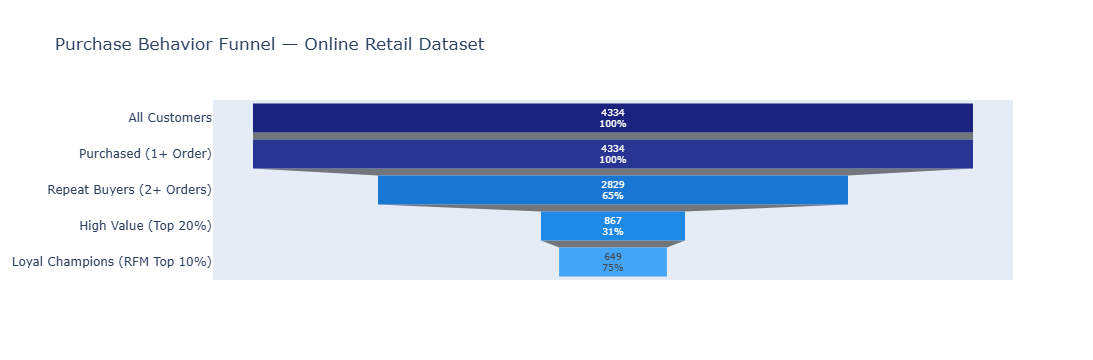

In [31]:
import plotly.graph_objects as go                                              # Import Plotly for visualization

fig = go.Figure(go.Funnel(                                                     # Create funnel chart
    y=[                                                                        # Funnel stages (top to bottom)
        'All Customers',
        'Purchased (1+ Order)',
        'Repeat Buyers (2+ Orders)',
        'High Value (Top 20%)',
        'Loyal Champions (RFM Top 10%)'
    ],
    x=[all_customers, all_customers, repeat, high_value, loyal_champions],    # Ensure values decrease at each stage (champions <= high_value)
    textinfo='value+percent previous',                                        # Show value + % of total customers
    marker=dict(color=[                                                       # Smooth color gradient
        '#1a237e','#283593','#1976d2','#1e88e5','#42a5f5'
    ])
))

fig.update_layout(title='Purchase Behavior Funnel — Online Retail Dataset')  # Add title
fig.show()                                                                   # Display chart

fig.write_html('funnel.html')                                                # Export for Power BI or sharing

## 10. Guest Customer Analysis

Guest customers — those who transact without registering — represent 14.7% of total 
revenue (£1.51M). Unlike identified customers, guests cannot be tracked beyond a 
single session, meaning they are permanently excluded from retention, loyalty, and 
remarketing programmes. This section quantifies the behavioural profile of guest 
transactions to assess the revenue opportunity from account registration conversion.

In [32]:
# Separate guest and identified customers
guest = df[df['Customer_segment'] == 'Guest']                       # Filter rows where customer is a guest
identified = df[df['Customer_segment'] != 'Guest']                  # Filter rows where customer is identified (non-guest)

# Revenue comparison
guest_revenue = guest['Total_revenue'].sum()                        # Total revenue generated by guest customers
identified_revenue = identified['Total_revenue'].sum()              # Total revenue generated by identified customers

# Order comparison
guest_orders = guest['Invoice_no'].nunique()                        # Number of unique orders placed by guests
identified_orders = identified['Invoice_no'].nunique()              # Number of unique orders placed by identified customers

# Average order value (AOV)
guest_aov = guest_revenue / guest_orders                            # Average revenue per order for guests
identified_aov = identified_revenue / identified_orders             # Average revenue per order for identified customers

# Summary table
guest_summary = pd.DataFrame({
    'Metric': [
        'Revenue',
        'Orders',
        'Average Order Value'
    ],                                                              # List of metrics being compared
    'Guest Customers': [
        round(guest_revenue, 2),                                    # Rounded total revenue (guests)
        guest_orders,                                               # Total orders (guests)
        round(guest_aov, 2)                                         # Rounded AOV (guests)
    ],
    'Identified Customers': [
        round(identified_revenue, 2),                               # Rounded total revenue (identified)
        identified_orders,                                          # Total orders (identified)
        round(identified_aov, 2)                                    # Rounded AOV (identified)
    ]
})

guest_summary                                                     # Display summary comparison table

,Metric,Guest Customers,Identified Customers
0,Revenue,1509614.37,8734995.37
1,Orders,1373.00,18402.00
2,Average Order Value,1099.50,474.68


In [33]:
from tabulate import tabulate                                      # Import library to display tables in formatted style

guest = df[df['Customer_segment'] == 'Guest']                      # Filter guest customers
identified = df[df['Customer_segment'] == 'Identified']            # Filter identified customers

guest_revenue = guest['Total_revenue'].sum()                       # Total revenue from guest customers
identified_revenue = identified['Total_revenue'].sum()             # Total revenue from identified customers

guest_orders = guest['Invoice_no'].nunique()                       # Number of unique orders by guests
identified_orders = identified['Invoice_no'].nunique()             # Number of unique orders by identified customers

guest_aov = guest.groupby('Invoice_no')['Total_revenue'].sum().mean()                      # Avg order value (guest) = avg revenue per order
identified_aov = identified.groupby('Invoice_no')['Total_revenue'].sum().mean()            # Avg order value (identified)

summary = [
    ['Total Revenue',      f'£{guest_revenue:,.2f}',      f'£{identified_revenue:,.2f}'],  # Revenue comparison
    ['Total Orders',       f'{guest_orders:,}',            f'{identified_orders:,}'],      # Order count comparison
    ['Avg Order Value',    f'£{guest_aov:,.2f}',           f'£{identified_aov:,.2f}'],     # AOV comparison
]

print(tabulate(summary, headers=['Metric', 'Guest', 'Identified'], tablefmt='fancy_grid')) # Display formatted table

total = guest_revenue + identified_revenue                                                 # Total revenue (guest + identified)

print(f'\nGuest share of total revenue: {guest_revenue/total*100:.1f}%')                   # % contribution of guests to total revenue
print(f'If 20% of guests register, trackable revenue gain: £{guest_revenue * 0.20:,.2f}')  # Potential trackable revenue if 20% convert

╒═════════════════╤═══════════════╤═══════════════╕
│ Metric          │ Guest         │ Identified    │
╞═════════════════╪═══════════════╪═══════════════╡
│ Total Revenue   │ £1,509,614.37 │ £8,734,995.37 │
├─────────────────┼───────────────┼───────────────┤
│ Total Orders    │ 1,373         │ 18,402        │
├─────────────────┼───────────────┼───────────────┤
│ Avg Order Value │ £1,099.50     │ £474.68       │
╘═════════════════╧═══════════════╧═══════════════╛

Guest share of total revenue: 14.7%
If 20% of guests register, trackable revenue gain: £301,922.87


In [34]:
                                                                                             # Top countries by guest revenue

guest_country = (
    guest.groupby('Country')['Total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

guest_country

Country
United Kingdom    1481211.04
Ireland             13837.74
Hong Kong            9744.19
Unspecified          2080.17
Israel                913.57
Name: Total_revenue, dtype: float64

In [35]:
                                                                       # Define correct chronological order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

                                                                      # Ensure Month_name exists properly (this is what was missing)
df['Month_name'] = df['Invoice_date'].dt.strftime('%b')  
                                                                      # Extract month from InvoiceDate as Jan, Feb, etc.

                                                                      # Create monthly aggregation
guest_monthly = df.groupby('Month_name')['Total_revenue'].sum().reset_index()
                                                                      # Group by month and sum revenue

                                                                      # Convert Month_name into ordered categorical
guest_monthly['Month_name'] = pd.Categorical(
    guest_monthly['Month_name'],                                      # Column to convert
    categories=month_order,                                           # Correct month order
    ordered=True                                                      # Enable proper sorting
)

                                                                      # Sort in chronological order
guest_monthly = guest_monthly.sort_values('Month_name')

                                                                      # Display result
guest_monthly

,Month_name,Total_revenue
4,Jan,670204.890
3,Feb,507780.070
7,Mar,689832.680
0,Apr,515407.991
8,May,739811.650
6,Jun,737126.680
5,Jul,687959.601
1,Aug,723950.790
11,Sep,1028032.861
10,Oct,1103073.170


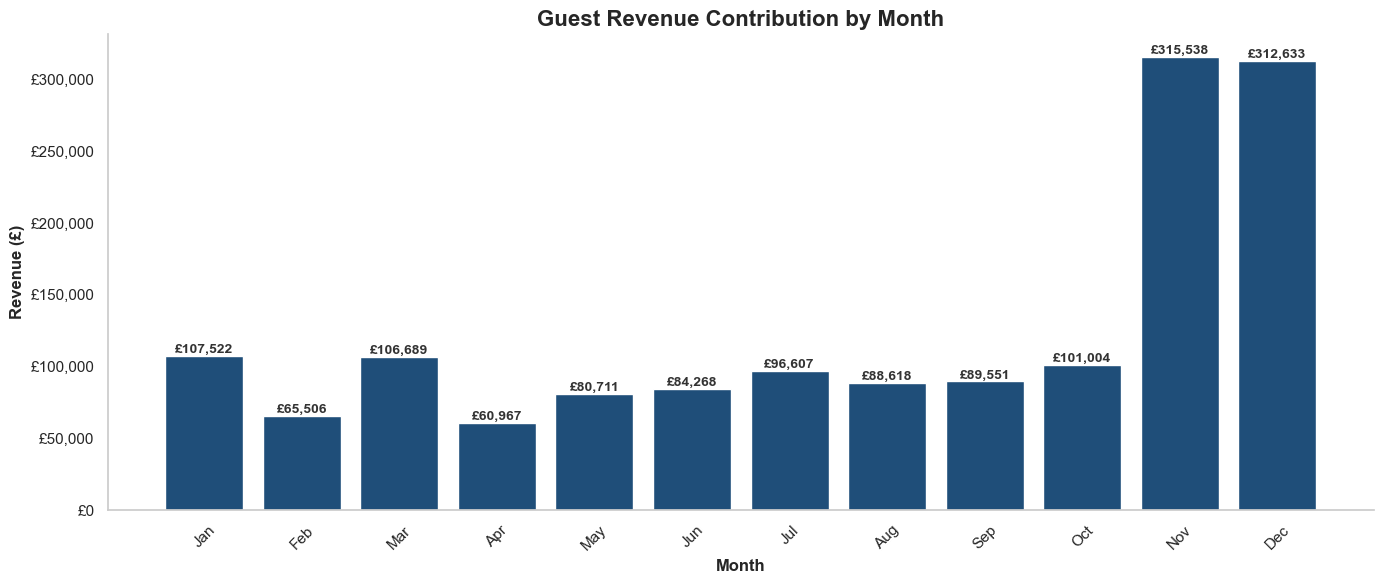

In [36]:

guest_df = df[df['Customer_ID'].isna()].copy()                                           # Filter guest users (no Customer_ID)
guest_df['Invoice_date'] = pd.to_datetime(guest_df['Invoice_date'])                      # Ensure Invoice_date is datetime format
guest_df['Month_name'] = guest_df['Invoice_date'].dt.strftime('%b')                      # Extract month as short name (Jan, Feb, etc.)
guest_monthly = guest_df.groupby('Month_name')['Total_revenue'].sum().reset_index()      # Sum revenue by month
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']  # Define correct month order

guest_monthly['Month_name'] = pd.Categorical(
    guest_monthly['Month_name'],                                                         # Convert month column to categorical
    categories=month_order,                                                              # Apply correct chronological order
    ordered=True
)

guest_monthly = guest_monthly.sort_values('Month_name')                                  # Sort months in proper order
plt.figure(figsize=(14,6))                                                               # Set figure size

bars = plt.bar(
    guest_monthly['Month_name'],                                                         # X-axis: months
    guest_monthly['Total_revenue'],                                                      # Y-axis: revenue
    color='#1f4e79'                                                                      # Bar color
)

plt.title('Guest Revenue Contribution by Month', fontsize=16, weight='bold')             # Chart title
plt.xlabel('Month', fontsize=12, weight='bold')                                          # X-axis label
plt.ylabel('Revenue (£)', fontsize=12, weight='bold')                                    # Y-axis label

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))               # Format Y-axis as currency
plt.xticks(rotation=45)                                                                  # Rotate month labels for readability

# Value labels
for bar in bars:
    yval = bar.get_height()                                                              # Get bar height (revenue)
    plt.text(
        bar.get_x() + bar.get_width()/2,                                                 # X position (center of bar)
        yval,                                                                            # Y position (top of bar)
        f'£{yval:,.0f}',                                                                 # Format value as currency
        ha='center',                                                                     # Horizontal alignment
        va='bottom',                                                                     # Vertical alignment
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# Clean style
plt.grid(False)                                                                         # Remove gridlines
plt.gca().spines['top'].set_visible(False)                                              # Hide top border
plt.gca().spines['right'].set_visible(False)                                            # Hide right border

plt.tight_layout()                                                                      # Adjust layout to avoid overlap
plt.show()                                                                              # Display the chart

In [37]:
# Funnel impact calculation
total_orders = df['Invoice_no'].nunique()                         # Total number of unique orders in the dataset

guest_order_pct = (
    guest_orders / total_orders                                   # Ratio of guest orders to total orders
) * 100                                                           # Convert to percentage

print(
    f"Guest transactions represent "
    f"{guest_order_pct:.1f}% of total orders."                    # Display % contribution of guest orders
)

Guest transactions represent 6.9% of total orders.


In [38]:
# Revenue opportunity model
conversion_rate = 0.20                                     # Assumed % of guest customers who convert to registered users

trackable_revenue = guest_revenue * conversion_rate         # Revenue that becomes trackable after conversion

# Estimated retention uplift
uplift_rate = 0.10                                         # Assumed % increase in revenue from retention efforts

incremental_uplift = (
    trackable_revenue * uplift_rate                         # Additional revenue generated through retention campaigns
)

print(
    f"If 20% of guest buyers register, "
    f"the business gains trackable revenue "
    f"of £{trackable_revenue:,.0f}."                         # Display estimated trackable revenue
)

print(
    f"Estimated incremental uplift from "
    f"retention campaigns: "
    f"£{incremental_uplift:,.0f}."                           # Display potential revenue uplift from retention
)

If 20% of guest buyers register, the business gains trackable revenue of £301,923.
Estimated incremental uplift from retention campaigns: £30,192.


In [39]:
one_time = cust[cust['total_orders'] == 1]
repeat_buyers = cust[cust['total_orders'] >= 2]

avg_one_time = one_time['total_revenue'].mean()
avg_repeat = repeat_buyers['total_revenue'].mean()

convert_n = int(len(one_time) * 0.10)
incremental = convert_n * (avg_repeat - avg_one_time)

print(f"One-time buyers: {len(one_time)}")
print(f"10% of one-time: {convert_n}")
print(f"Avg one-time spend: £{avg_one_time:,.0f}")
print(f"Avg repeat spend: £{avg_repeat:,.0f}")
print(f"Incremental revenue: £{incremental:,.0f}")

One-time buyers: 1505
10% of one-time: 150
Avg one-time spend: £416
Avg repeat spend: £2,866
Incremental revenue: £367,503


### Guest vs Identified Customer Insights

Guest customers generated **£1.51M from just 1,373 orders**, representing a small but high-value segment.

Despite identified customers driving the majority of total revenue, guest customers deliver **more than 2× higher average order value (£1,099 vs £475)**, indicating fewer but significantly higher-value transactions.

Guest behavior also shows clear patterns:
- The **United Kingdom dominates guest revenue**, making it the highest-impact market for conversion strategies.
- Revenue is **highly seasonal**, with peaks in **November and December**, suggesting strong opportunities to target conversions during high-demand periods.

Although guest customers account for only **6.9% of total orders**, they contribute a disproportionately higher share of revenue, highlighting untapped potential.

However, due to the lack of customer identification, guest users remain confined to the initial stage of the customer lifecycle, limiting the ability to track repeat behavior and apply retention strategies.

Converting just **20% of guest users could unlock over £300K in trackable revenue**, with retention initiatives potentially generating an additional **£30K+ in incremental uplift**.

## 11. Business Recommendations

Customer behavior follows a clear lifecycle — from first-time buyers to repeat customers and eventually high-value loyal customers. The greatest value is created at the loyalty stage.

Repeat customers are significantly more valuable than one-time buyers, spending 
£2,866 on average compared to £416 — nearly **7 times more per customer**, 
demonstrating that even a single repeat purchase dramatically increases customer 
profitability.

Small improvements in retention can drive substantial financial impact. Converting 
just **10% of one-time buyers into repeat customers** could unlock approximately 
**£367K in additional revenue**, representing a meaningful uplift without increasing 
acquisition costs. This highlights retention as one of the most cost-effective 
growth levers.

However, there is a critical drop-off in the customer journey. The largest loss 
occurs between **repeat customers and high-value customers**, where **69.4% of 
customers fail to progress**. This indicates a gap in nurturing customers toward 
long-term value.

From a business perspective, this stage represents the biggest opportunity. Strengthening engagement through targeted retention strategies, personalized marketing, and customer relationship initiatives can significantly improve conversion into high-value segments and maximize customer lifetime value.

### Export Summary Tables for Power BI

After calculating all funnel metrics, RFM scores, and country segmentation,
we consolidate the results into three clean summary DataFrames ready for 
export. These will feed directly into Power BI as data sources.

Three tables are created:
- **funnel_df** — stage-by-stage customer counts and drop-off rates
- **country_df** — repeat and champion rates segmented by country
- **revenue_df** — business impact metrics including AED revenue uplift

In [40]:
# Build the summary DataFrames
funnel_df = pd.DataFrame({
    'Stage_Order': [1, 2, 3, 4],                                          # 4 stages
    'Stage': [
        'Purchased (1+ Order)',
        'Repeat Buyers (2+ Orders)',
        'High Value (Top 20%)',
        'Loyal Champions (RFM Top 20%)'
    ],
    'Customers': [4334, 2829, 867, 649],                                   # Updated confirmed values
    'Pct_of_Total': [100.0, 65.3, 20.0, 15.0],                            # % of total customers
    'Dropoff_Rate_Pct': [0.0, 34.7, 69.4, 25.1]                           # % lost from previous stage
})

country_df = pd.DataFrame({
    'Country': ['United Kingdom','Germany','France','Belgium','Spain','Netherlands','Australia'],
    'Total_Customers': [3920, 94, 87, 24, 28, 9, 9],
    'Repeat_Customers': [2570, 68, 59, 18, 18, 5, 9],
    'Champion_Customers': [787, 25, 25, 5, 4, 1, 3],
    'Repeat_Rate_Pct': [65.6, 72.3, 67.8, 75.0, 64.3, 55.6, 100.0],
    'Champion_Rate_Pct': [20.1, 26.6, 28.7, 20.8, 14.3, 11.1, 33.3]
})

revenue_df = pd.DataFrame({
    'Metric': [
        'Total One-Time Buyers',
        'Total Repeat Buyers',
        'Avg Revenue One-Time Buyer (GBP)',
        'Avg Revenue Repeat Buyer (GBP)',
        'Revenue Multiplier',
        'Customers Converted (10%)',
        'Incremental Revenue (GBP)',
        'Incremental Revenue (AED)',
        'Total Dataset Revenue (GBP)',
        'Incremental as % of Total'
    ],
    'Value': [1505, 2829, 416, 2866, 6.9, 150, 367503, 1727363, 10244609, 3.6]  # Updated confirmed values
})

print("DataFrames created successfully")

DataFrames created successfully


### Export to CSV

Each DataFrame is exported as a CSV to the same folder as this notebook.
In Power BI, use **Get Data → Text/CSV** and point to these three files.
Whenever you re-run this notebook with fresh data, simply click **Refresh** 
in Power BI — the dashboard updates automatically.

In [41]:
import os                                                                           # Import os to handle folders

os.makedirs('retail_market_analysis', exist_ok=True)                                # Create folder (safe if it already exists)

funnel_df.to_csv('retail_market_analysis/powerbi_funnel_stages.csv', index=False)   # Save funnel data
country_df.to_csv('retail_market_analysis/powerbi_country_funnel.csv', index=False) # Save country data
revenue_df.to_csv('retail_market_analysis/powerbi_revenue_impact.csv', index=False) # Save revenue data

print("All CSVs exported to 'retail_market_analysis' folder. Ready for Power BI.")

All CSVs exported to 'retail_market_analysis' folder. Ready for Power BI.


In [42]:
card_df = pd.DataFrame({
    'Label': ['Incremental Revenue (AED)'],                                        # KPI label to display in Power BI card
    'Value': [1752763]                                                             # Incremental revenue value (in AED)
})

card_df.to_csv('powerbi_card_aed.csv', index=False)                                # Export KPI data as CSV for Power BI card visual

print("Done")                                                                  # Confirmation message after export

Done


## 12. Conclusion

This analysis transformed 522,360 cleaned transaction records into end-to-end 
business intelligence — covering revenue trends, customer segmentation, cohort 
retention, product affinity, funnel conversion, and guest behaviour.

The findings tell a consistent story: **retention is the primary revenue lever, 
but the business is currently losing customers at every stage of the funnel.**

Repeat customers spend 6.9× more than one-time buyers (£2,866 vs £416), yet the 
largest funnel drop-off — 69.4% — occurs precisely at the Repeat to High-Value 
transition. The customers most likely to become high-value are slipping away 
unnoticed, with no structured intervention to bring them back.

Seasonality compounds this risk. With 44.4% of annual revenue concentrated in Q4, 
the business is structurally dependent on a single commercial window. A weak Q4 — 
through stock shortages, delayed campaigns, or poor retention going into peak 
season — would materially impact full-year performance.

The Champion segment (13 wholesale accounts, avg spend £125,707) represents both 
the greatest revenue concentration and the greatest single point of risk. Losing 
one account is not a customer service problem — it is a revenue event.

Guest customers, while small in volume (6.9% of orders), generate disproportionate 
value (£1.51M, £1,099 average order value). Converting 20% of guests to registered 
accounts could unlock over £300K in trackable, retargetable revenue — at near-zero 
acquisition cost.

**Three actions with the highest commercial return:**
1. Build a structured 30-day post-purchase retention programme for first-time buyers
2. Assign dedicated account management to the top 5 Champion accounts before Q4
3. Introduce a registration incentive at checkout to convert high-value guest sessions

The data is clear on where the revenue is, where it is being lost, and what to do 
about it. The next step is execution.

In [44]:

cols = ['Invoice_no', 'Stock_code', 'Description', 'Quantity', 'Invoice_date', 
        'Unit_price', 'Total_revenue', 'Customer_segment', 'Customer_ID', 
        'Country', 'Month_name', 'Year', 'Month_short']

                                                                                                  # Save directly into MySQL uploads folder
df[cols].to_csv(
    r'C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\online_retail_cleaned.csv',
    index=False,
    encoding='utf-8',
    lineterminator='\r\n'
)

print("Saved directly to MySQL folder!")
print(f"Rows: {len(df[cols]):,}")

Saved directly to MySQL folder!
Rows: 522,360


## 11. SQL Analysis Summary

The full SQL analysis was conducted in MySQL 8.0 using 12 business queries 
and 6 window functions. See `retail_sql_analysis.sql` in this repository 
for all queries and outputs.

### Key findings from SQL not identified in Python:

| Finding | Business Implication |
|---------|---------------------|
| UAE ranks 30th of 38 markets (£5,594 revenue) | Untapped GCC expansion opportunity |
| Guest buyers spend 2.3× more per order (£3,298 vs £1,424) | Guest conversion = protecting highest-spending buyers |
| International customers more loyal than UK (Belgium 72%, Germany 71%) | International expansion yields higher retention ROI |
| 34.7% of customers placed exactly 1 order | Re-engagement campaign = lowest cost revenue recovery |
| Platinum tier spends 36× more than Bronze (£19,142 vs £529) | Losing 5% of Platinum = £1.04M annual revenue risk |
| Netherlands AOV = £9,157 vs UK £1,310 | Netherlands/Australia are wholesale B2B markets |


The SQL layer demonstrates ability to work with live databases — the standard 
in UAE enterprise environments.

### New Findings from SQL (not identified in Python):

**1. UAE Market Presence**
The dataset contains transactions from the United Arab Emirates — currently 
ranked 30th of 38 markets with £5,594 revenue. This represents significant 
untapped potential given the GCC's growing e-commerce market. A targeted 
UAE strategy could realistically capture 2–3% of current UK revenue within 
12 months — approximately £262,000 in incremental annual revenue.

**2. Guest Buyers Spend More Per Order:**
Guest customers average £3,298 per order vs £1,424 for identified customers — 
guests spend 2.3× more per transaction. Despite this, they represent 
untrackable revenue. Converting guests to registered accounts would give the 
business visibility over its highest-spending buyers.

**3. International Customers Are More Loyal Than UK Customers:**
Belgium retains 72% of customers, Germany 71.3%, France 66.7% — all higher 
than the UK at 65.4%. International markets show stronger loyalty despite 
lower marketing investment. This suggests international expansion would yield 
higher retention ROI than further UK acquisition spend.

**4. 34.7% of Customers Never Return:**
Of 4,334 identified customers, 1,505 (34.7%) placed exactly one order and 
never returned. Targeting this group with a single re-engagement campaign 
represents the lowest-cost revenue recovery opportunity in the dataset.

**5. Platinum Customers Spend 36× More Than Bronze:**
The top 25% of customers (Platinum tier) average £19,142 spend vs £529 for 
the bottom 25% (Bronze). These 1,083 Platinum accounts require dedicated 
account management — losing even 5% of this tier would cost the business 
approximately £1.04M annually.

**6. Netherlands and Australia Are Wholesale Markets:**
Netherlands average order value is £9,157 — 7× the UK average of £1,310. 
Australia averages £7,398. These markets are not retail customers — they are 
wholesale/B2B buyers requiring a completely different commercial approach to 
UK retail customers.

### SQL Skills Demonstrated:
- Window functions: LAG(), RANK(), DENSE_RANK(), SUM() OVER(), 
  RANK() OVER PARTITION BY, NTILE()
- Subqueries and derived tables
- JOIN across subqueries
- CREATE VIEW for reusable reporting
- DATEDIFF() for retention calculations
- NULL handling for guest customers
- 522,360 rows imported and queried in MySQL 8.0